# Image augmentation

In [ ]:
# ! pip install albumentations opencv-python numpy
import cv2
import numpy as np
import albumentations as A
import os

def load_yolo_annotations(txt_path):
    """Load YOLO annotations from a .txt file."""
    boxes = []
    with open(txt_path, "r") as f:
        for line in f.readlines():
            values = line.strip().split()
            class_id = int(values[0])
            x_center, y_center, width, height = map(float, values[1:])
            boxes.append([x_center, y_center, width, height, class_id])
    return boxes

def save_yolo_annotations(txt_path, boxes):
    """Save YOLO annotations to a .txt file."""
    with open(txt_path, "w") as f:
        for box in boxes:
            f.write(f"{int(box[4])} {box[0]} {box[1]} {box[2]} {box[3]}\n")

def augment_image(image, bboxes):
    """Perform augmentations while skipping invalid ones."""
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Affine(scale=(0.95, 1.05), translate_percent=(-0.05, 0.05), rotate=(-10, 10), p=0.5)
    ], bbox_params=A.BboxParams(format='yolo', label_fields=[]))

    try:
        transformed = transform(image=image, bboxes=[b[:4] for b in bboxes])

        # Check if any bounding box is invalid
        for bbox in transformed["bboxes"]:
            if any(coord < 0 or coord > 1 for coord in bbox):
                print("Skipping augmentation due to invalid bbox:", bbox)
                return image, bboxes

        return transformed["image"], transformed["bboxes"]

    except Exception as e:
        print("Error during augmentation:", e)
        return image, bboxes  # Skip and return original data

def augment_dataset(original_images_dir, original_labels_dir):
    """Augment dataset and save only the augmented images and labels."""
    image_files = [f for f in os.listdir(original_images_dir) if f.endswith(('.jpg', '.JPG'))]

    for img_file in image_files:
        img_path = os.path.join(original_images_dir, img_file)
        label_path = os.path.join(original_labels_dir, img_file.replace('.jpg', '.txt').replace('.JPG', '.txt'))
        
        if not os.path.exists(label_path):
            continue

        image = cv2.imread(img_path)

        # Load YOLO bounding boxes (normalized values)
        boxes = load_yolo_annotations(label_path)

        # Generate and save augmented image and annotations
        augmented_image, augmented_boxes = augment_image(image, boxes)

        # Preserve original class labels
        aug_boxes = [b + [boxes[i][4]] for i, b in enumerate(augmented_boxes)]

        # Save augmented image and label
        aug_img_name = f"aug_{img_file}"
        aug_label_name = f"aug_{img_file.replace('.jpg', '.txt').replace('.JPG', '.txt')}"
        cv2.imwrite(os.path.join(original_images_dir, aug_img_name), augmented_image)
        save_yolo_annotations(os.path.join(original_labels_dir, aug_label_name), aug_boxes)

# Define dataset directories
original_images_dir = "/home/aojwang/data/yolo_dataset/val/images"
original_labels_dir = "/home/aojwang/data/yolo_dataset/val/labels"

# Process and save the augmented dataset
augment_dataset(original_images_dir, original_labels_dir)

## Visualize augmented images

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import random

# Define dataset directories
image_dir = "/home/aojwang/data/yolo_dataset/val/images"
label_dir = "/home/aojwang/data/yolo_dataset/val/labels"

# Dynamically list all images starting with "aug_"
augmented_images = [img for img in os.listdir(image_dir) if img.startswith("aug_")]

# Count total images and labels
total_images = len(os.listdir(image_dir))
total_labels = len(os.listdir(label_dir))
total_augmented = len(augmented_images)

print(f"Total Images: {total_images}")
print(f"Total Labels: {total_labels}")
print(f"Total Augmented Images: {total_augmented}")

# Choose a random augmented image for visualization
if total_augmented == 0:
    print("No augmented images found.")
else:
    random_image = random.choice(augmented_images)
    image_path = os.path.join(image_dir, random_image)
    
    # Handle different file extensions
    label_path = os.path.join(label_dir, random_image.rsplit(".", 1)[0] + ".txt")

    # Function to read YOLO annotations
    def read_yolo_annotations(txt_file):
        boxes = []
        if not os.path.exists(txt_file):
            print(f"Warning: Label file not found for {random_image}")
            return boxes
        with open(txt_file, "r") as f:
            for line in f:
                values = line.strip().split()
                class_id = int(values[0])
                x_center, y_center, width, height = map(float, values[1:])
                boxes.append((class_id, x_center, y_center, width, height))
        return boxes

    # Read image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for display

    # Read bounding boxes
    bboxes = read_yolo_annotations(label_path)
    print(bboxes)
    h, w, _ = image.shape  # Get image dimensions

    # Draw bounding boxes
    for class_id, x_center, y_center, width, height in bboxes:
        x1 = int((x_center - width / 2) * w)
        y1 = int((y_center - height / 2) * h)
        x2 = int((x_center + width / 2) * w)
        y2 = int((y_center + height / 2) * h)

        # Draw rectangle and label
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 5)
        cv2.putText(image, f"Class {class_id}", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    # Display the image with bounding boxes
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Augmented Image: {random_image}")
    plt.show()


# Train yolo model

In [ ]:
from ultralytics import YOLO 

model = YOLO("yolo11n.pt")
# results = model.train(data="/home/aojwang/data/yolo_dataset2/yolo.yaml", epochs=50, hsv_v=0.5, translate=0.2, scale=0.3, shear=10, erasing=0.2, batch=4, imgsz=640, project="runs/train",  name='yolo11_food_detection')
# model = YOLO("yolov8n.pt")
results = model.train(data="/home/aojwang/data/yolo_dataset/yolo.yaml",epochs=120,batch=4,imgsz=640,hsv_v=0.5,translate=0.2,scale=0.3,shear=10,erasing=0.2,flipud=0.3,fliplr=0.5,mosaic=1.0,mixup=0.5,box=0.05,cls=0.5,dfl=1.5,project="runs/train",name='yolo11_food_detection_improved')

New https://pypi.org/project/ultralytics/8.3.160 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.69 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A10G, 22836MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/home/aojwang/data/yolo_dataset/yolo.yaml, epochs=120, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/train, name=yolo11_food_detection_improved7, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retin

train: Scanning /opt/dlami/nvme/aojwang/yolo_dataset/train/labels.cache... 9652 images, 640 backgrounds, 0 corrupt: 100%|██████████| 

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /opt/dlami/nvme/aojwang/yolo_dataset/val/labels.cache... 2758 images, 188 backgrounds, 0 corrupt: 100%|██████████| 2758


Plotting labels to runs/train/yolo11_food_detection_improved7/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/train/yolo11_food_detection_improved7
Starting training for 120 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

IOPub message rate exceeded.09234      1.298      1.515         12        640:   4%|▍         | 100/2413 [00:24<08:10,  4.71it/s]
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 345/345 [01:35<00:00,  3.6


                   all       2758       4142      0.796      0.822      0.868      0.577

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     74/120      1.06G   0.009107      1.298      1.508         18        640: 100%|██████████| 2413/2413 [09:07<00:00,  4.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 345/345 [01:34<00:00,  3.6


                   all       2758       4142      0.808      0.807       0.87      0.581

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     75/120      1.06G    0.00915      1.309      1.513         14        640:  39%|███▉      | 947/2413 [03:36<04:06,  5.94it/s]  

## References
* https://github.com/ultralytics/ultralytics/issues/2789 *

# Label detection scatter plot

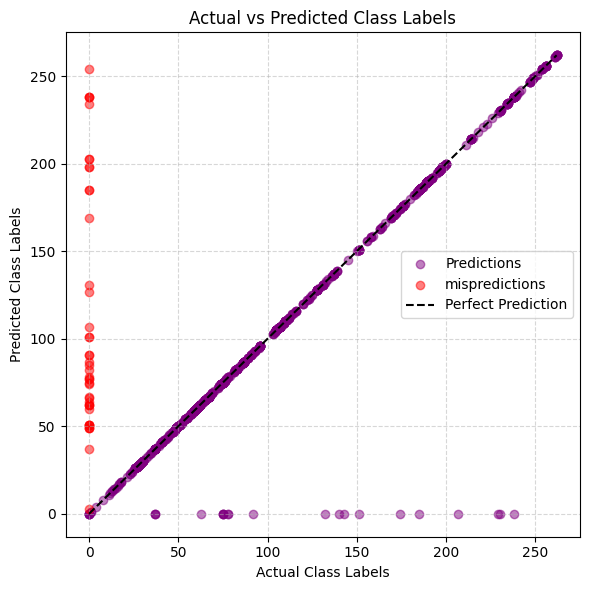

In [32]:
from ultralytics import YOLO
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Load the trained YOLO model
# model = YOLO("/home/aojwang/data/model/model/CarboAI/runs/train/AUG3_food_detection2/weights/best.pt")
model = YOLO("/home/aojwang/data/model/model/CarboAI/runs/train/yolo11_food_detection_improved6/weights/best.pt")

# Load all image paths (case-insensitive JPG/JPEG)
image_paths = glob('/home/aojwang/data/y1_dataset2/val/images/*')
image_paths = [p for p in image_paths if p.lower().endswith(('.jpg'))]

actual_classes = [] # np.zeros(len(image_paths))
predicted_classes =  []  # np.zeros(len(image_paths))
misactual_classes = []
mispredicted_classes = []

for im_index, img_path in enumerate(image_paths):
    # Check for corresponding label
    label_path = img_path.replace('images', 'labels')
    label_path = os.path.splitext(label_path)[0] + '.txt'
    
    if not os.path.exists(label_path):
        continue  # skip image if no label
    actual_class = []
    with open(label_path, 'r') as f:
        lines = f.readlines()
        targets = [int(line.split()[0]) for line in lines]
        actual_class.extend(targets)
        #print("actual", targets)
    
    results = model(img_path, verbose=False)
    predicted_class = []
    for r in results:
        if len(r.boxes) > 0:
            preds = r.boxes.cls.cpu().numpy().astype(int)
            predicted_class.extend( [x.item() for x in preds])
    #print("predicted", predicted_class)
    for item in actual_class:
        if item in predicted_class:
            actual_classes.append(item)    # ground truth
            predicted_classes.append(item) # predicted, accurately
        else:
            actual_classes.append(item)   # ground truth
            predicted_classes.append(0)   # missing ground truth labels 
            
    for item in predicted_class:
        if item not in actual_class:
            mispredicted_classes.append(item) # predicted but not  ground truth
            misactual_classes.append(0)       # placeholder to help with plotting
    #break
    
# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(actual_classes, predicted_classes, alpha=0.5, color='purple', label='Predictions')
plt.scatter(misactual_classes, mispredicted_classes, alpha=0.5, color='red', label='mispredictions')

# Dotted y = x reference line
max_val = max(max(actual_classes), max(predicted_classes))
min_val = min(min(actual_classes), min(predicted_classes))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')

# Labels and title
plt.xlabel("Actual Class Labels")
plt.ylabel("Predicted Class Labels")
plt.title("Actual vs Predicted Class Labels")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

correct_predictions = sum([1 for a, p in zip(actual_classes, predicted_classes) if a == p and a != 0]) # excluding 
total_actuals = len([a for a in actual_classes if a != 0]) ## Total number of actual ground truth labels (excluding zeros
accuracy = correct_predictions / total_actuals if total_actuals > 0 else 0

# Filter out placeholders (assuming 0 is not a valid class)
filtered_actuals = [a for a, p in zip(actual_classes, predicted_classes) if a != 0 or p != 0]
filtered_preds = [p for a, p in zip(actual_classes, predicted_classes) if a != 0 or p != 0]

precision = precision_score(filtered_actuals, filtered_preds, average='macro', zero_division=0)
recall = recall_score(filtered_actuals, filtered_preds, average='macro', zero_division=0)
f1 = f1_score(filtered_actuals, filtered_preds, average='macro', zero_division=0)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")


Accuracy: 98.10%
Precision: 97.62%
Recall: 95.87%
F1 Score: 96.54%


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Accuracy
accuracy = np.mean(np.array(actual_classes) == np.array(predicted_classes))

# Precision, Recall, F1
precision = precision_score(actual_classes, predicted_classes, average='macro', zero_division=0)
recall = recall_score(actual_classes, predicted_classes, average='macro', zero_division=0)
f1 = f1_score(actual_classes, predicted_classes, average='macro', zero_division=0)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")


Accuracy: 98.02%
Precision: 97.75%
Recall: 96.26%
F1 Score: 96.64%


# Validate yolo model

In [26]:
from ultralytics import YOLO

# Load a model
model = YOLO("/home/aojwang/data/model/model/CarboAI/runs/train/yolo11_food_detection_improved6/weights/best.pt")

# Validate the model
metrics = model.val(data='/home/aojwang/data/y1_dataset2/v1.yaml', project='runs/val', save_json=True)

Ultralytics 8.3.69 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A10G, 22836MiB)
YOLO11n summary (fused): 238 layers, 2,697,280 parameters, 0 gradients, 6.9 GFLOPs


val: Scanning /opt/dlami/nvme/aojwang/y1_dataset2/val/labels.cache... 718 images, 50 backgrounds, 0 corrupt: 100%|██████████| 718/718
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 45/45 [00:14<00:00,  3.15i


                   all        718       1113      0.908       0.92      0.959      0.767
                 Beans          6          6          1      0.904      0.995      0.749
          Orange Juice          2          2          1      0.734      0.995      0.623
           Apple juice          1          1      0.941          1      0.995      0.796
     Carbonated Sprite          1          1          1          0      0.995      0.697
             Olive Oil          1          1      0.911          1      0.995      0.895
       Sunflower Seeds          1          1       0.84          1      0.995      0.796
          Sesame Seeds          2          2      0.901          1      0.995      0.895
         Pumpkin Seeds          2          2      0.952          1      0.995      0.895
           Poppy Seeds          1          1      0.833          1      0.995      0.895
                Peanut          1          1      0.838          1      0.995      0.895
            Mozzarell

# Visualize annotations

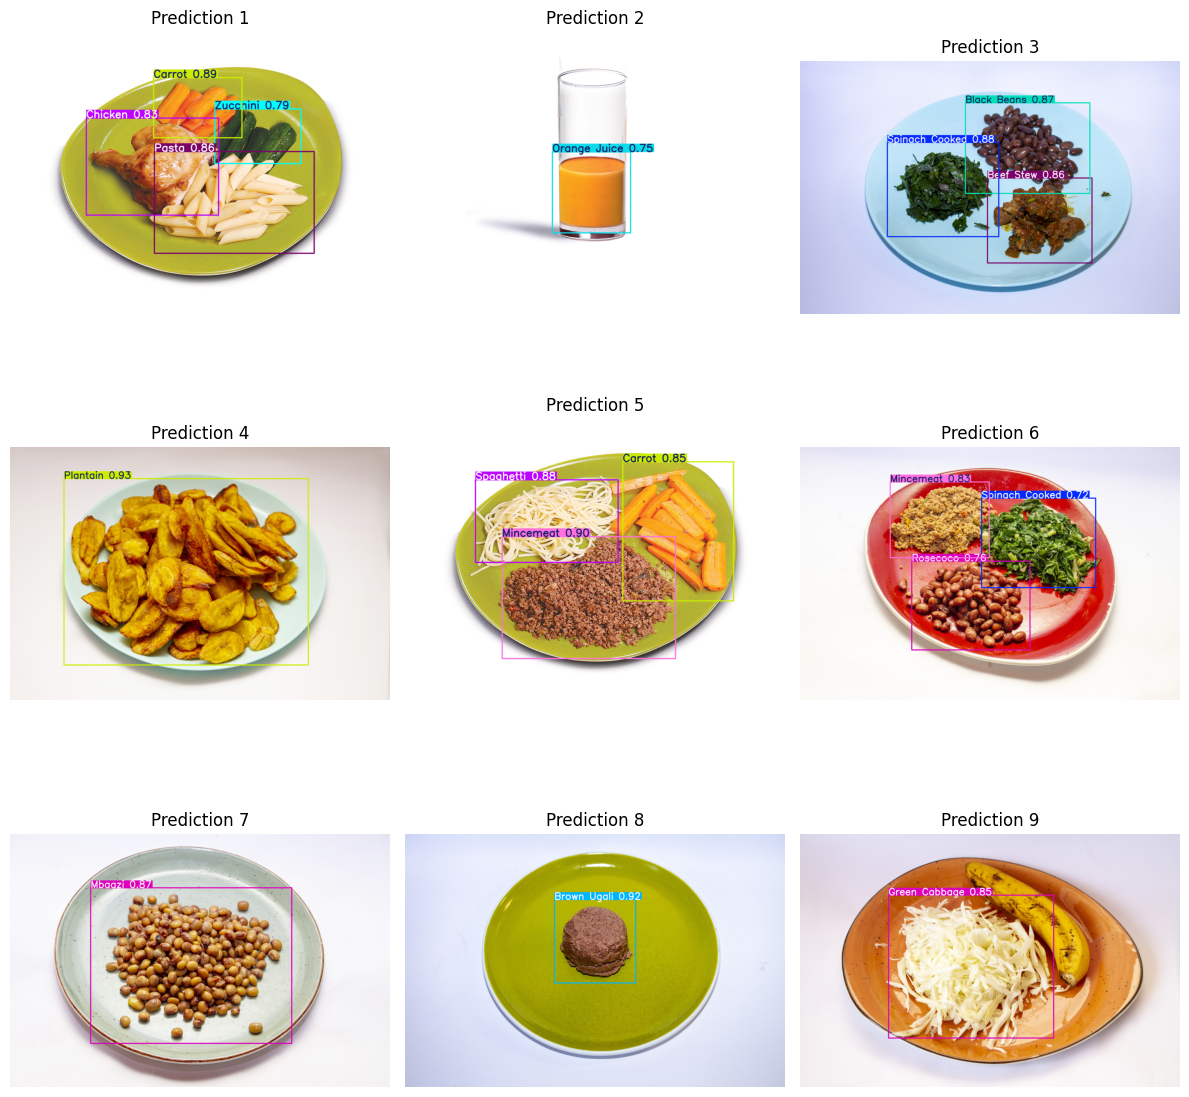

In [21]:
import os
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load YOLO model
model = YOLO("/home/aojwang/data/model/model/CarboAI/runs/train/yolo11_food_detection_improved4/weights/best.pt")

# Path to image directory
image_dir = "/home/aojwang/data/MergeDataset/images"
all_images = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".JPG",))]

# Select 9 random images
sample_images = random.sample(all_images, 9)

# Run batched inference
results = model(sample_images, verbose=False)

# Create 3x3 grid for displaying results
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

# Show each result directly using .plot()
for i, result in enumerate(results):
    annotated_img = result.plot()  
    axes[i].imshow(annotated_img[..., ::-1])
    axes[i].axis('off')
    axes[i].set_title(f"Prediction {i+1}")

plt.tight_layout()
plt.show()


#  Carbohydrate content estimation model
#### Steps
1. **Object Detection using YOLO.** Load the trained YOLO model. Pass each image through the model. Extract detected objects (bounding boxes, labels, confidences).
2. **Crop and Extract Features.** For each detected object: Crop the bounding box region, Save the cropped image & extract visual features (i.e., area, aspect ratio, Average pixel intensity).
3. **Parse the CSV**. Read the nutrition CSV file, Organize data as a dictionary: {image_name: list of {label, carb}} & Normalize image names and labels to avoid case mismatch.
4. **Match Predictions with Nutrition Info.** For each detected label in an image: Find the matching entry in the parsed CSV & Append label, features, and carbohydrate content to the dataset
5. **Create and Save Dataset.** Combine everything into a structured DataFrame.





In [43]:
import os
import cv2
import pandas as pd
import io
import numpy as np
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
import matplotlib.pyplot as plt
import contextlib
import shutil
from ultralytics.utils import LOGGER
import logging

# Configuration
YOLO_MODEL_PATH = "/home/aojwang/data/model/model/CarboAI/runs/train/yolo11_food_detection_improved4/weights/best.pt"
CSV_FILE = "/home/aojwang/data/MergeDataset/csv_files/found_merged.csv"
IMAGE_DIR = "/home/aojwang/data/MergeDataset/images"
CROP_DIR = "/home/aojwang/data/MergeDataset/cropped_images"
SUPPORTED_IMG_EXTS = ('.jpg', '.JPG')

def load_model():
    """
    Load a fine-tuned YOLO model for food detection.

    Returns:
        YOLO model object
    """
    model = YOLO(YOLO_MODEL_PATH)
    return model

def extract_features(img_array):
    """
    Extract custom features from a cropped RGB image.

    Args:
        img_array: Numpy array in RGB format.

    Returns:
        [area, aspect_ratio, average_rgb_intensity]
    """
    if isinstance(img_array, Image.Image): 
        img_array = np.array(img_array)

    if not isinstance(img_array, np.ndarray):
        raise ValueError("Input must be a NumPy RGB array or PIL Image.")
        
    h, w = img_array.shape[:2]
    area = w * h
    aspect_ratio = w / h if h > 0 else 0
    avg_intensity = np.mean(img_array)

    return [area, aspect_ratio, avg_intensity]



def detect_and_crop(model, image_dir, crop_dir, supported_exts=('.jpg', '.JPG')):
    """
    Pass images through YOLO model, crop each detected object,
    and extract features from the cropped region.

    Args:
        model: YOLO model instance.
        image_dir: Path to input images.
        crop_dir: Where to save cropped objects.
        supported_exts: Allowed image file extensions.

    Returns:z
        List of dicts with image name, label, features, and crop path.
    """
    image_dir = Path(image_dir)
    crop_dir = Path(crop_dir)

    # Clear the crop directory if it exists
    if crop_dir.exists():
        shutil.rmtree(crop_dir)
    crop_dir.mkdir(parents=True, exist_ok=True)
    
    feature_records = []

    for img_path in image_dir.glob('*'):
        if img_path.suffix.lower() not in supported_exts:
            continue

        img_name = img_path.name
        pil_image = Image.open(img_path).convert("RGB")
        
        # Suppress YOLO output
        LOGGER.setLevel(logging.CRITICAL) 
        results = model(img_path)

        result = results[0]

        for i, box in enumerate(result.boxes):
            cls_id = int(box.cls.item())
            label = model.names[cls_id].lower()
            conf = box.conf.item()
            if conf < 0.25:
                continue

            # Get bounding box coordinates
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

            # Crop using PIL
            crop_img = pil_image.crop((x1, y1, x2, y2))
            if crop_img.size[0] == 0 or crop_img.size[1] == 0:
                continue

            # Save crop
            save_dir = crop_dir / img_path.stem
            save_dir.mkdir(parents=True, exist_ok=True)
            crop_path = save_dir / f"{label}_{i}.jpg"
            crop_img.save(crop_path)
            
            # Extract features
            features = extract_features(crop_img)

            # Append metadata
            feature_records.append({
                'image': img_name,
                'label': label,
                'features': features,
                'crop_path': str(crop_path)
            })

    return feature_records


# model = load_model()
# print("📦 Detecting and cropping food items...")
# detect_and_crop(model, IMAGE_DIR, CROP_DIR)

In [45]:
def parse_nutrition_csv(csv_path):
    """
    Parses a nutrition CSV file to extract carbohydrate information.

    The CSV is expected to have rows structured such that:
    - A new image begins when a row's 'ospath' column ends with .jpg or .JPG
    - That row and the rows that follow contain the nutrition information for that food
    - An empty label row may contain summary totals for each nutrition info (ignore it)
    - For each label, we extract:
        - The `label` name (converted to lowercase)
        - The `CARBOHYDRATE CONTENT` as a float
        
    Parameters:
    - csv_path (str or Path): Path to the nutrition CSV file.

    Returns:
    - dict: Mapping {image_name → list of dicts with keys 'label' and 'carb'}
    """

    df = pd.read_csv(csv_path).fillna('')
    nutrition_data = defaultdict(list)
    current_image = None

    for _, row in df.iterrows():
        path = str(row['ospath']).strip()
        label = str(row['LABELS']).strip()

        # A new image block starts
        if path.lower().endswith(SUPPORTED_IMG_EXTS):
            current_image = Path(path).name  # extract only the filename
            # Process this row since it contains a valid label
            if label:
                try:
                    carb = float(row['CARBOHYDRATES AVAILABLE CARBOHYDRATE CONTENT/ (g)'])
                    nutrition_data[current_image].append({
                        'label': label.lower(),
                        'carb': carb
                    })
                except ValueError:
                    continue  # skip rows with invalid numeric values
            continue  # move to next row

        # Skip rows without an image or without a label
        if not current_image or not label:
            continue

        # Process valid label rows that belong to the current image
        try:
            carb = float(row['CARBOHYDRATES AVAILABLE CARBOHYDRATE CONTENT/ (g)'])
            nutrition_data[current_image].append({
                'label': label.lower(),
                'carb': carb
            })
        except ValueError:
            continue

    return nutrition_data
    
# if __name__ == "__main__":
#     SUPPORTED_IMG_EXTS = ('.jpg', '.JPG')
#     CSV_FILE = "/home/aojwang/data/MergeDataset/csv_files/found_merged.csv"
#     nutrition = parse_nutrition_csv(CSV_FILE)

#     # Print summary of parsed content
#     for image_name, items in list(nutrition.items())[:5]:  # Show first 5 only
#         print(f"\n📷 {image_name}")
#         for item in items:
#             print(f"  🍽️ {item['label']} - {item['carb']}g carbs")


In [46]:
def build_dataset(crops, nutrition_lookup):
    """
    Combine cropped image data with matching nutrition data.

    Args:
        crops (list): List of dicts from detect_and_crop.
        nutrition_lookup (dict): Parsed nutrition info from CSV.

    Returns:
        pd.DataFrame: Combined dataset for training carbohydrate estimation.
    """
    records = []
    for item in crops:
        image = item['image']
        label = item['label']
        features = item['features']
        crop_path = item['crop_path']

        match = next((x for x in nutrition_lookup.get(image, []) if x['label'] == label), None)
        if match:
            records.append({
                'image': image,
                'label': label,
                'area': features[0],
                'aspect_ratio': features[1],
                'avg_intensity': features[2],
                'carb': match['carb'],
                'crop_path': crop_path
            })

    return pd.DataFrame(records)

if __name__ == "__main__":
    print("📦 Detecting and cropping food items...")
    model = load_model()
    crops = detect_and_crop(model, IMAGE_DIR, CROP_DIR)

    print("🧾 Parsing nutrition CSV...")
    nutrition_data = parse_nutrition_csv(CSV_FILE)

    print("📊 Building final dataset...")
    dataset = build_dataset(crops, nutrition_data)

    if dataset.empty:
        print("⚠️ No matching records found.")
    else:
        print("✅ Dataset created with", len(dataset), "records")
        print(dataset.head())
    dataset.to_csv("debug_dataset.csv", index=False)

📦 Detecting and cropping food items...
🧾 Parsing nutrition CSV...
📊 Building final dataset...
✅ Dataset created with 3402 records
                                               image        label     area  \
0                               341LettuceOnions.jpg       onions  2015028   
1                               341LettuceOnions.jpg      lettuce  3074084   
2  1651WholeFishKachumbarithirdCupBrownUgalihalfC...  brown ugali  1363548   
3  1651WholeFishKachumbarithirdCupBrownUgalihalfC...   kachumbari  1984734   
4  1651WholeFishKachumbarithirdCupBrownUgalihalfC...     fish fry  5434968   

   aspect_ratio  avg_intensity    carb  \
0      0.888446     142.794743    1.50   
1      1.183002     173.343895    1.20   
2      1.045534     106.288632    1.90   
3      1.215180     101.086844    0.92   
4      2.665266     109.495712  126.43   

                                           crop_path  
0  /home/aojwang/data/MergeDataset/cropped_images...  
1  /home/aojwang/data/MergeDataset/cro

In [28]:
# df['crop_path']
df.columns
# df.head()

Index(['image', 'label', 'area', 'aspect_ratio', 'avg_intensity', 'carb',
       'crop_path'],
      dtype='object')

In [47]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch
import numpy as np
import os

class FoodRegressionDataset(Dataset):
    """
    A custom PyTorch Dataset for food image regression tasks that combines image data
    with tabular features (e.g., area, aspect ratio, average intensity).

    Attributes:
        df (pd.DataFrame): DataFrame containing file paths to cropped images and tabular features.
        transform (callable): Optional transform to be applied to the images.
    """
    def __init__(self, dataframe, transform=None):
        """
        Initializes the dataset with a DataFrame and optional image transforms.

        Args:
            dataframe (pd.DataFrame): Must contain columns:
                - 'crop_path': file path to cropped image
                - 'area': area of the food bounding box
                - 'aspect_ratio': width/height of the food object
                - 'avg_intensity': mean pixel intensity
                - 'carb': target carbohydrate value
            transform (callable, optional): torchvision-style transform pipeline for image preprocessing.
        """
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        """Returns the total number of samples."""
        return len(self.df)

    def __getitem__(self, idx):
        """
        Fetches the image, tabular features, and target carb value for a given index.

        Args:
            idx (int): Index of the item to retrieve.

        Returns:
            tuple: (image_tensor, tabular_tensor, target_tensor)
                - image_tensor: processed image [C x H x W]
                - tabular_tensor: tensor of [area, aspect_ratio, avg_intensity]
                - target_tensor: target carbohydrate value
        """
        row = self.df.iloc[idx]

        # Load and transform image
        image = Image.open(row["crop_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Convert tabular features to a tensor
        tabular_feats = torch.tensor([
            row["area"],
            row["aspect_ratio"],
            row["avg_intensity"]
        ], dtype=torch.float32)

        # Convert target value to a tensor
        target = torch.tensor(row["carb"], dtype=torch.float32)

        return image, tabular_feats, target

def create_dataloader_from_dataframe(df, batch_size=32, shuffle=True, transform=None):
    """
    Creates a PyTorch DataLoader for the regression task using the given DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing:
            - 'crop_path': path to the cropped food images
            - 'area', 'aspect_ratio', 'avg_intensity': tabular features
            - 'carb': target variable
        batch_size (int, optional): Number of samples per batch. Default is 32.
        shuffle (bool, optional): Whether to shuffle the data. Default is True.
        transform (callable, optional): Optional image transforms. If None, a default transform is applied.

    Returns:
        torch.utils.data.DataLoader: A DataLoader ready for training or validation.
    """
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    dataset = FoodRegressionDataset(df, transform=transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


In [150]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import pandas as pd
import random
import os

# ========================
# Transform Definitions
# ========================

def get_base_transform():
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((256, 256)),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

# Dictionary of augmentation transforms
AUGMENTATION_TRANSFORMS = {
    "rotation": transforms.Compose([
        transforms.RandomRotation(20),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    "translation": transforms.Compose([
        transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    "hflip": transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    "vflip": transforms.Compose([
        transforms.RandomVerticalFlip(p=1.0),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    "blur": transforms.Compose([
        transforms.GaussianBlur(kernel_size=9, sigma=3),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    "color_jitter": transforms.Compose([
        transforms.ColorJitter(brightness=0.9, contrast=0.4, saturation=0.2, hue=0.1),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}


# ========================
# Dataset Definition
# ========================

class FoodRegressionDataset(Dataset):
    def __init__(self, df, transform=None, augment=False, scaler=None, label_encoder=None):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.base_transform = transform or get_base_transform()
        self.scaler = scaler
        self.label_encoder = label_encoder

        # Extract tabular features and optionally scale
        features = self.df[["area", "aspect_ratio", "avg_intensity"]].values
        self.features = scaler.transform(features) if scaler else features

        # Encode labels
        labels = self.df["label"].values
        self.labels = label_encoder.transform(labels) if label_encoder else labels

        # Targets
        self.targets = self.df["carb"].values

        # List of all augmentation transforms
        self.augmentations = list(AUGMENTATION_TRANSFORMS.values())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["crop_path"]
        image = Image.open(img_path).convert("RGB")

        # Decide which transform to use
        if self.augment:
            transform = random.choice(self.augmentations)
        else:
            transform = self.base_transform

        image_tensor = transform(image)

        # Get tabular features and convert to tensor
        tabular_tensor = torch.tensor(self.features[idx], dtype=torch.float32)

        # Get label and target
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        target = torch.tensor(self.targets[idx], dtype=torch.float32)

        return {
            "image": image_tensor,
            "tabular": tabular_tensor,
            "label": label,
            "target": target
        }


Evaluating model performance...

image 1/1 /home/aojwang/data/MergeDataset/images/1Chickpeas.jpg: 544x640 1 Chick Peas, 8.7ms
Speed: 3.4ms preprocess, 8.7ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 640)

image 1/1 /home/aojwang/data/MergeDataset/images/924Mandazi.jpg: 448x640 (no detections), 8.6ms
Speed: 3.0ms preprocess, 8.6ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/aojwang/data/MergeDataset/images/1BeefRoast.jpg: 544x640 1 Beef Roast, 8.3ms
Speed: 3.3ms preprocess, 8.3ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 640)

image 1/1 /home/aojwang/data/MergeDataset/images/681WhiteChapati.jpg: 448x640 1 White Chapati, 8.7ms
Speed: 2.9ms preprocess, 8.7ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/aojwang/data/MergeDataset/images/1AvocadoCabbage.jpg: 544x640 1 Avocado Green Cabbage, 8.9ms
Speed: 4.0ms preprocess, 8.9ms inference, 1.4ms postprocess per image at shape (1, 3, 5

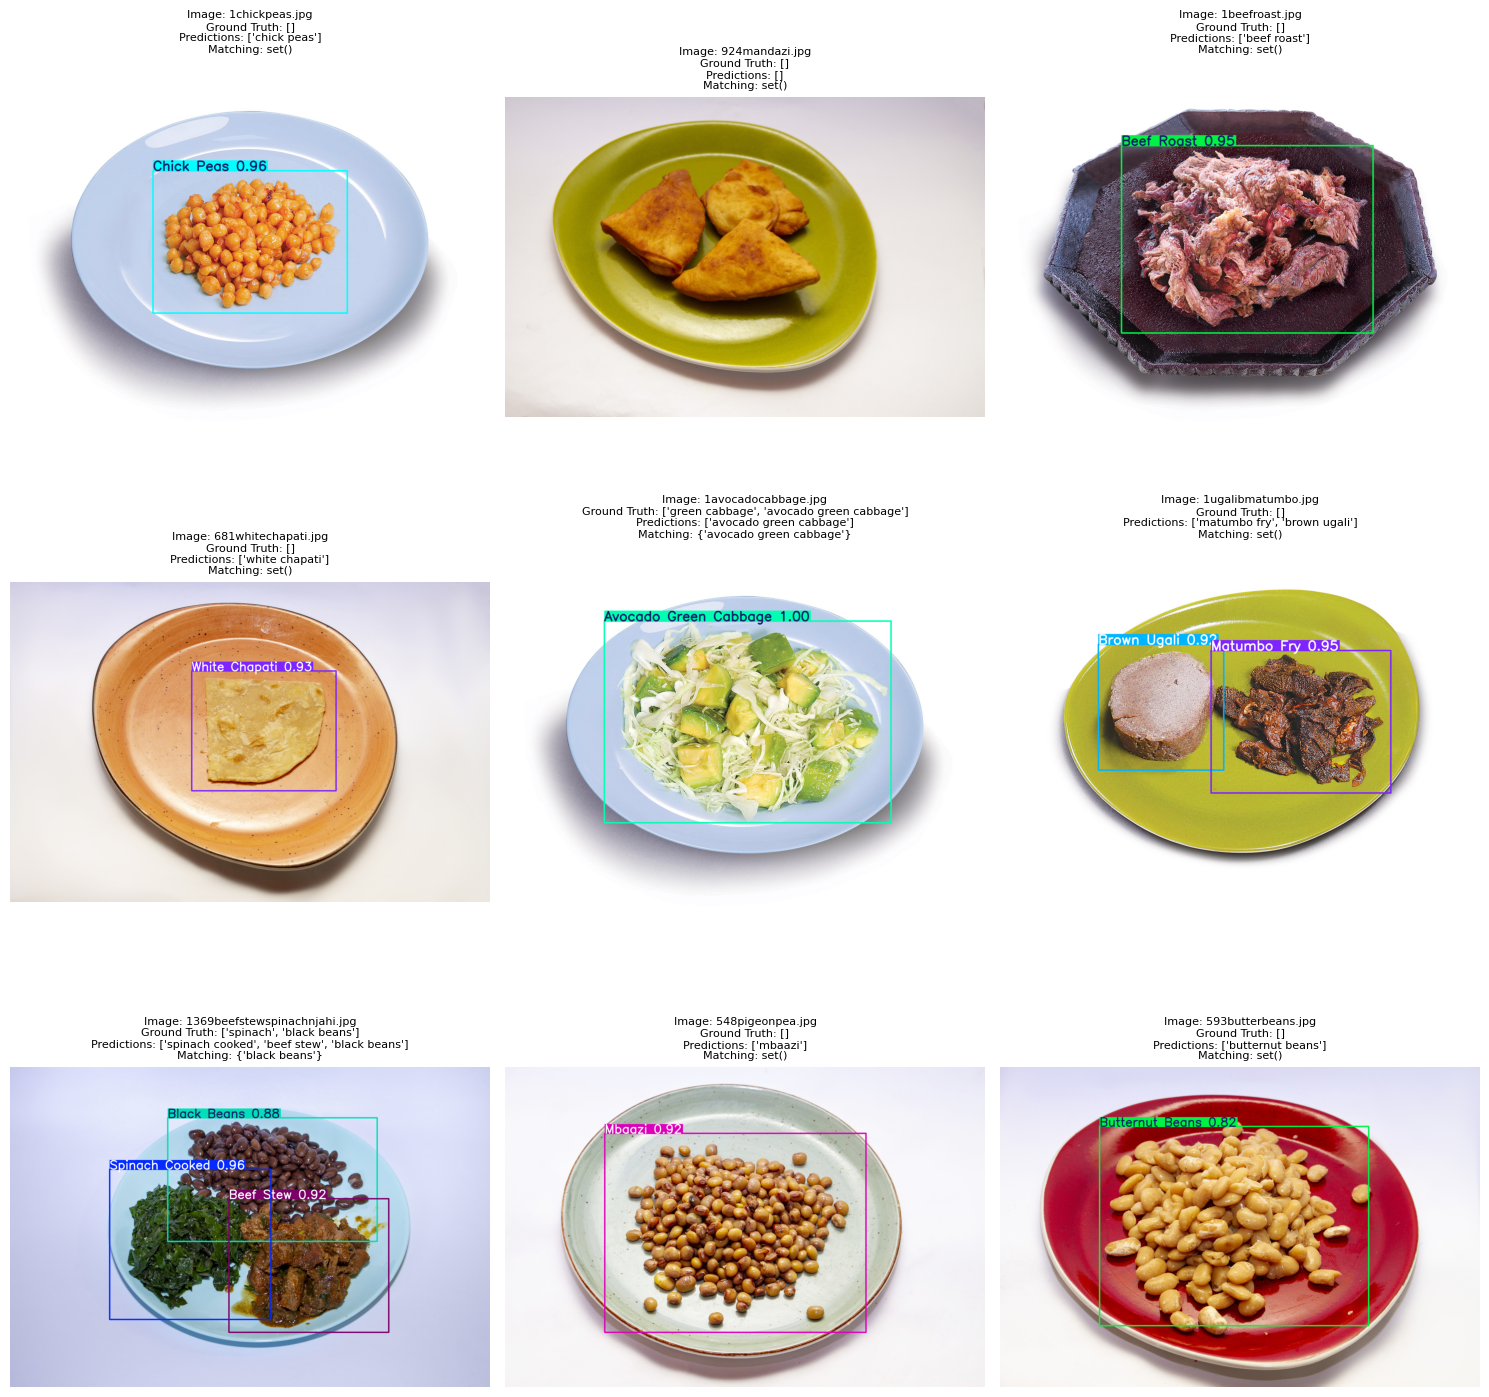


Processing images for feature extraction...

image 1/1 /home/aojwang/data/MergeDataset/images/341LettuceOnions.jpg: 448x640 1 Lettuce, 1 Onions, 7.8ms
Speed: 2.7ms preprocess, 7.8ms inference, 4.8ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/aojwang/data/MergeDataset/images/1651WholeFishKachumbarithirdCupBrownUgalihalfCup.JPG: 448x640 1 Fish Fry, 1 Kachumbari, 1 Brown Ugali, 7.7ms
Speed: 2.8ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/aojwang/data/MergeDataset/images/913SweetPotatoroundcut.jpg: 448x640 1 Sweet Potato, 11.9ms
Speed: 2.6ms preprocess, 11.9ms inference, 4.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/aojwang/data/MergeDataset/images/1561UgaliBrown2Cups.JPG: 448x640 1 Brown Ugali, 7.8ms
Speed: 2.7ms preprocess, 7.8ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/aojwang/data/MergeDataset/images/214MangoAvocado.jpg: 448x640 (no detectio

In [22]:
import os
import cv2
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
import contextlib

# Configuration
YOLO_MODEL_PATH = "/home/aojwang/data/model/model/CarboAI/runs/train/yolo11_food_detection_improved9/weights/best.pt"
CSV_FILE = "/home/aojwang/data/MergeDataset/csv_files/found_merged.csv"
IMAGE_DIR = "/home/aojwang/data/MergeDataset/images"
SUPPORTED_IMG_EXTS = ('.jpg', '.JPG')

def load_model():
    """Load YOLO model with suppressed output"""
    with contextlib.redirect_stdout(None): 
        model = YOLO(YOLO_MODEL_PATH)
    model.verbose = False
    return model

def parse_nutrition_csv(csv_path):
    df = pd.read_csv(csv_path).fillna('')
    nutrition_data = defaultdict(list)
    current_image = None

    for _, row in df.iterrows():
        if isinstance(row.iloc[0], str) and row.iloc[0].strip().lower().endswith(SUPPORTED_IMG_EXTS):
            current_image = Path(row.iloc[0].strip()).name.lower().strip()
            continue

        label = str(row.get('LABELS', '')).strip().lower()
        if not label or not current_image:
            continue

        try:
            carb = float(row.get('CARBOHYDRATE CONTENT', 0))
        except ValueError:
            carb = 0

        nutrition_data[current_image].append({'label': label, 'carb': carb})

    return nutrition_data

def evaluate_model_performance(model, image_dir, nutrition_data, num_samples=9):
    """Display model predictions vs ground truth for visual evaluation"""
    image_paths = [str(p) for p in Path(image_dir).glob('*') if p.suffix.lower() in SUPPORTED_IMG_EXTS]
    sample_paths = np.random.choice(image_paths, min(num_samples, len(image_paths)), replace=False)

    plt.figure(figsize=(15, 15))
    for i, img_path in enumerate(sample_paths, 1):
        img_name = Path(img_path).name.lower().strip()
        ground_truth_list = nutrition_data.get(img_name, [])
        gt_labels = [item['label'] for item in ground_truth_list]

        # Run inference
        results = model(img_path)
        result = results[0]

        # Get predicted labels
        pred_labels = [model.names[int(cls)].lower() for cls in result.boxes.cls]

        # Prepare display
        comparison_text = [
            f"Image: {img_name}",
            f"Ground Truth: {gt_labels}",
            f"Predictions: {pred_labels}",
            f"Matching: {set(pred_labels) & set(gt_labels)}"
        ]

        # Show image
        plt.subplot(3, 3, i)
        annotated_img = result.plot()  # YOLO draws on BGR
        plt.imshow(annotated_img[..., ::-1])  # Convert BGR to RGB
        plt.title('\n'.join(comparison_text), fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


def process_images(model, image_dir, crop_dir, nutrition_data):
    feature_data = []
    
    for img_path in Path(image_dir).glob('*'):
        if img_path.suffix.lower() not in SUPPORTED_IMG_EXTS:
            continue

        img_name = img_path.name
        img_nutrition = nutrition_data.get(img_name, [])

        # Run inference
        results = model(img_path)
        result = results[0]
        
        # Create output directory
        output_dir = Path(crop_dir) / img_path.stem
        output_dir.mkdir(parents=True, exist_ok=True)

        # Track matched labels to avoid duplicates
        matched_labels = set()

        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            label = model.names[int(box.cls)].lower()
            conf = box.conf.item()

            if conf < 0.25 or label in matched_labels:
                continue

            # Find matching nutrition data
            nutrition = next((n for n in img_nutrition if n['label'] == label), None)
            if not nutrition:
                continue

            # Crop and save (RGB preserved)
            crop = result.orig_img[y1:y2, x1:x2]
            crop_path = output_dir / f"{label}.jpg"
            Image.fromarray(crop).save(crop_path)

            # Extract features
            features = extract_image_features(crop_path)
            feature_data.append({
                'image': img_name,
                'label': label,
                'features': features,
                'carb': nutrition['carb'],
            })

            matched_labels.add(label)
    
    return feature_data

def extract_image_features(img_path):
    """Extract features from cropped image"""
    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img)
    h, w = img_array.shape[:2]
    
    return [
        w * h,                         # Area
        w / h if h > 0 else 0,         # Aspect ratio
        np.mean(img_array[:, :, 0]),   # Mean R
        np.mean(img_array[:, :, 1]),   # Mean G
        np.mean(img_array[:, :, 2])    # Mean B
    ]

def main():
    # Initialize
    model = load_model()
    nutrition_data = parse_nutrition_csv(CSV_FILE)
    
    # Step 1: Evaluate model performance
    print("Evaluating model performance...")
    evaluate_model_performance(model, IMAGE_DIR, nutrition_data)
    
    # Step 2: Process all images
    print("\nProcessing images for feature extraction...")
    feature_data = process_images(model, IMAGE_DIR, CROP_DIR, nutrition_data)
    
    # Convert to DataFrame
    df = pd.DataFrame(feature_data)
    if not df.empty:
        # Encode labels
        le = LabelEncoder()
        df['label_encoded'] = le.fit_transform(df['label'])
        
        # Expand features
        feature_cols = ['area', 'aspect_ratio', 'mean_R', 'mean_G', 'mean_B']
        df[feature_cols] = pd.DataFrame(df['features'].tolist(), index=df.index)
        
        print("\nFinal dataset:")
        print(df[['image', 'label', 'carb'] + feature_cols].head())
    else:
        print("Warning: No valid samples were processed!")

if __name__ == "__main__":
    main()

#### Train the Carbohydrate Regression Model

Using device: cuda


Extracting features: 100%|██████████████████████| 22/22 [00:04<00:00,  5.35it/s]


[0]	validation_0-mae:0.99096	validation_1-mae:1.00458
[100]	validation_0-mae:0.25170	validation_1-mae:0.52417
[199]	validation_0-mae:0.13661	validation_1-mae:0.49119


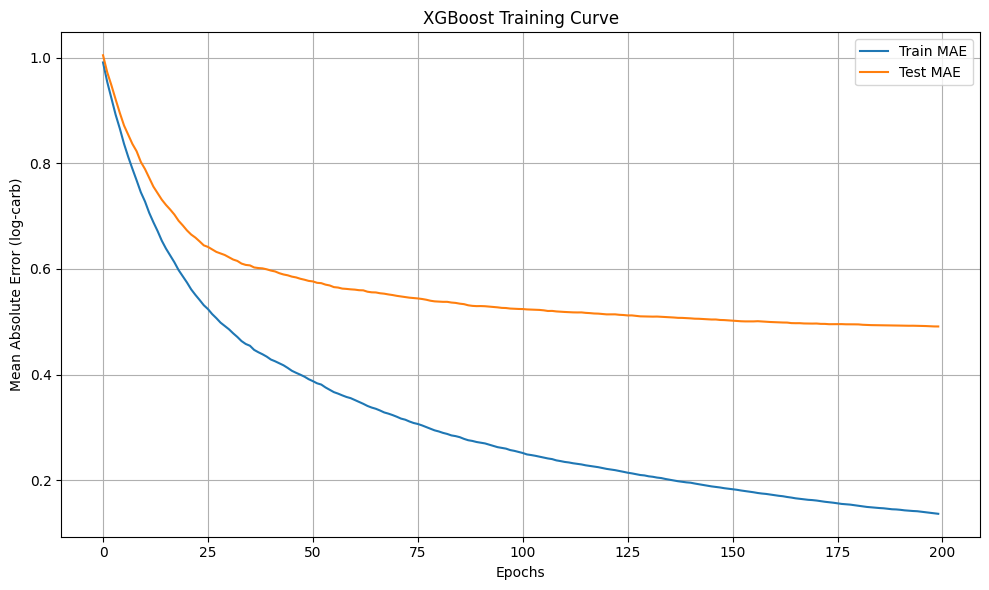


Evaluation Metrics:
- Test MAE: 7.5008 grams
- Test MSE: 309.5091
- Test RMSE: 17.5929 grams
- Test R²: 0.5206
- Test MAPE: 270541357056.00%


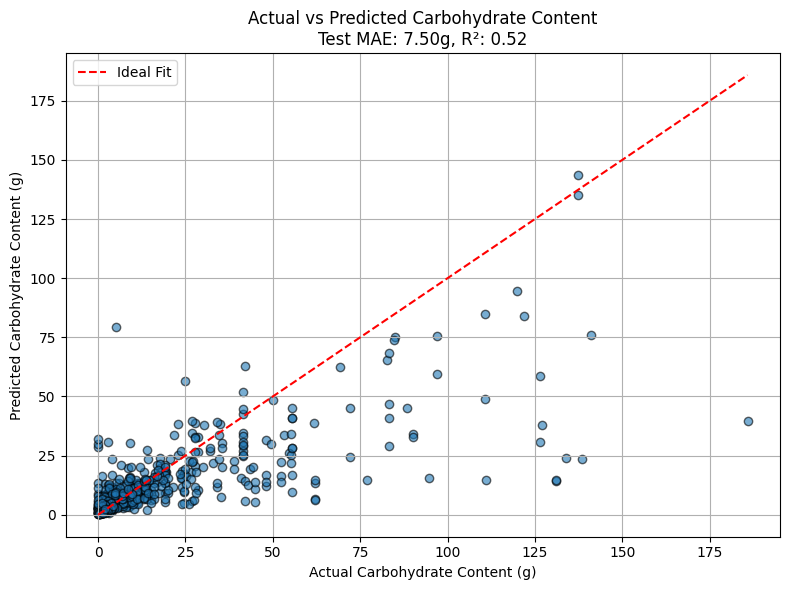

In [96]:
# Xgboost
import torch
from torchvision import transforms
from torchvision.models import efficientnet_b0
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import os
from PIL import Image
import warnings

# Suppress warnings if desired
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# 1. Normalize tabular features and log-transform target
def preprocess_dataframe(df):
    df = df.copy()
    
    # Handle missing values if any
    df.fillna({
        'area': df['area'].median(),
        'aspect_ratio': df['aspect_ratio'].median(),
        'avg_intensity': df['avg_intensity'].median(),
        'carb': df['carb'].median()
    }, inplace=True)
    
    # Log transform target with small epsilon to avoid log(0)
    df['log_carbs'] = np.log1p(df['carb'])  # Better than log(x + epsilon)
    
    # Standardize features
    scaler = StandardScaler()
    numeric_cols = ['area', 'aspect_ratio', 'avg_intensity']
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    
    return df, scaler

# 2. Image feature extractor using EfficientNet
class ImageFeatureExtractor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        model = efficientnet_b0(pretrained=True)
        
        # Freeze all layers
        for param in model.parameters():
            param.requires_grad = False
            
        # Remove classifier and keep only feature extractor
        self.backbone = torch.nn.Sequential(*list(model.children())[:-1])
        self.pool = torch.nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        features = self.backbone(x)
        pooled = self.pool(features)
        return pooled.view(x.size(0), -1)

# 3. Extract features
def extract_features(model, dataloader, device):
    model.eval()
    image_feats = []
    tabular_feats = []
    targets = []

    with torch.no_grad():
        for img, tabular, target in tqdm(dataloader, desc="Extracting features"):
            img = img.to(device)
            tabular = tabular.to(device)
            target = target.to(device)

            img_feat = model(img)

            image_feats.append(img_feat.cpu().numpy())
            tabular_feats.append(tabular.cpu().numpy())
            targets.append(target.cpu().numpy())

    image_feats = np.concatenate(image_feats, axis=0)
    tabular_feats = np.concatenate(tabular_feats, axis=0)
    targets = np.concatenate(targets, axis=0)

    full_feats = np.hstack([image_feats, tabular_feats])
    return full_feats, targets

# 4. Dataset class
class FoodRegressionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image with error handling
        try:
            image = Image.open(row['crop_path']).convert('RGB')
        except Exception as e:
            print(f"Error loading image at {row['crop_path']}: {e}")
            # Return a blank image if loading fails
            image = Image.new('RGB', (224, 224))
            
        image = self.transform(image)
        
        tabular = torch.tensor([
            row['area'],
            row['aspect_ratio'],
            row['avg_intensity']
        ], dtype=torch.float32)
        
        target = torch.tensor(row['log_carbs'], dtype=torch.float32)
        
        return image, tabular, target

# 5. Main script
def main():
    # Setup device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Load and preprocess data
    try:
        df = pd.read_csv("/home/aojwang/data/model/model/CarboAI/debug_dataset.csv")
        df, scaler = preprocess_dataframe(df)
    except Exception as e:
        print(f"Error loading or processing data: {e}")
        return

    # Split data
    try:
        train_df, test_df = train_test_split(
            df, 
            test_size=0.2, 
            random_state=SEED,
            stratify=pd.qcut(df['log_carbs'], q=5)  # Stratify by target quantiles
        )
    except Exception as e:
        print(f"Error splitting data: {e}")
        return

    # Create datasets and dataloaders
    train_ds = FoodRegressionDataset(train_df)
    test_ds = FoodRegressionDataset(test_df)
    
    train_loader = DataLoader(
        train_ds, 
        batch_size=32, 
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, 
        batch_size=32, 
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # Initialize feature extractor
    try:
        feature_extractor = ImageFeatureExtractor().to(device)
        feature_extractor.eval()
    except Exception as e:
        print(f"Error initializing feature extractor: {e}")
        return

    # Extract features
    try:
        X_train, y_train = extract_features(feature_extractor, train_loader, device)
        X_test, y_test = extract_features(feature_extractor, test_loader, device)
    except Exception as e:
        print(f"Error extracting features: {e}")
        return

    # Train XGBoost
    try:
        xgb_model = xgb.XGBRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=4,
            subsample=0.7,
            colsample_bytree=0.7,
            min_child_weight=3,      
            gamma=0.2,       
            reg_alpha=0.5, 
            reg_lambda=0.5, 
            random_state=SEED,
            verbosity=1,
            eval_metric="mae",
            early_stopping_rounds=50,
            n_jobs=-1
        )

        xgb_model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100
        )
    except Exception as e:
        print(f"Error training XGBoost: {e}")
        return

    # Plot training curves
    try:
        results = xgb_model.evals_result()
        epochs = len(results['validation_0']['mae'])
        
        plt.figure(figsize=(10, 6))
        plt.plot(range(epochs), results['validation_0']['mae'], label='Train MAE')
        plt.plot(range(epochs), results['validation_1']['mae'], label='Test MAE')
        plt.xlabel("Epochs")
        plt.ylabel("Mean Absolute Error (log-carb)")
        plt.title("XGBoost Training Curve")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error plotting training curves: {e}")

    # Predict and inverse transform
    try:
        pred_log = xgb_model.predict(X_test)
        true_log = y_test
    
        pred_carb = np.expm1(pred_log)  # Inverse of log1p
        true_carb = np.expm1(true_log)
    
        # Calculate metrics
        mae = np.mean(np.abs(pred_carb - true_carb))
        mse = np.mean((pred_carb - true_carb)**2)
        rmse = np.sqrt(mse)
        r2 = 1 - (np.sum((true_carb - pred_carb)**2) / np.sum((true_carb - np.mean(true_carb))**2))
        
        # Calculate MAPE (Mean Absolute Percentage Error)
        # Adding small epsilon to avoid division by zero
        epsilon = 1e-10
        mape = np.mean(np.abs((true_carb - pred_carb) / (true_carb + epsilon))) * 100
        
        print("\nEvaluation Metrics:")
        print(f"- Test MAE: {mae:.4f} grams")
        print(f"- Test MSE: {mse:.4f}")
        print(f"- Test RMSE: {rmse:.4f} grams")
        print(f"- Test R²: {r2:.4f}")
        print(f"- Test MAPE: {mape:.2f}%")
    
        # Plot actual vs predicted
        plt.figure(figsize=(8, 6))
        plt.scatter(true_carb, pred_carb, alpha=0.6, edgecolors='k')
        plt.plot([min(true_carb), max(true_carb)], [min(true_carb), max(true_carb)], 'r--', label='Ideal Fit')
        plt.xlabel("Actual Carbohydrate Content (g)")
        plt.ylabel("Predicted Carbohydrate Content (g)")
        plt.title(f"Actual vs Predicted Carbohydrate Content\nTest MAE: {mae:.2f}g, R²: {r2:.2f}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        # # Plot residual plot
        # plt.figure(figsize=(8, 6))
        # residuals = pred_carb - true_carb
        # plt.scatter(pred_carb, residuals, alpha=0.6)
        # plt.axhline(y=0, color='r', linestyle='--')
        # plt.xlabel("Predicted Values")
        # plt.ylabel("Residuals")
        # plt.title("Residual Plot")
        # plt.grid(True)
        # plt.tight_layout()
        # plt.show()
        
    except Exception as e:
        print(f"Error in evaluation: {e}")

if __name__ == "__main__":
    main()


Epoch 1/50


Validating: 100%|███████████████████████████████| 22/22 [00:04<00:00,  4.98it/s]


Train Loss: 0.7783 | Val Loss: 0.2912
✅ Saved best model.

Epoch 2/50


Validating: 100%|███████████████████████████████| 22/22 [00:04<00:00,  5.01it/s]


Train Loss: 0.2839 | Val Loss: 0.2067
✅ Saved best model.

Epoch 3/50


...

Train Loss: 0.0633 | Val Loss: 0.0959

Epoch 49/50


Validating: 100%|███████████████████████████████| 22/22 [00:04<00:00,  5.00it/s]


Train Loss: 0.0580 | Val Loss: 0.0944

Epoch 50/50


Validating: 100%|███████████████████████████████| 22/22 [00:04<00:00,  5.05it/s]


Train Loss: 0.0613 | Val Loss: 0.0921


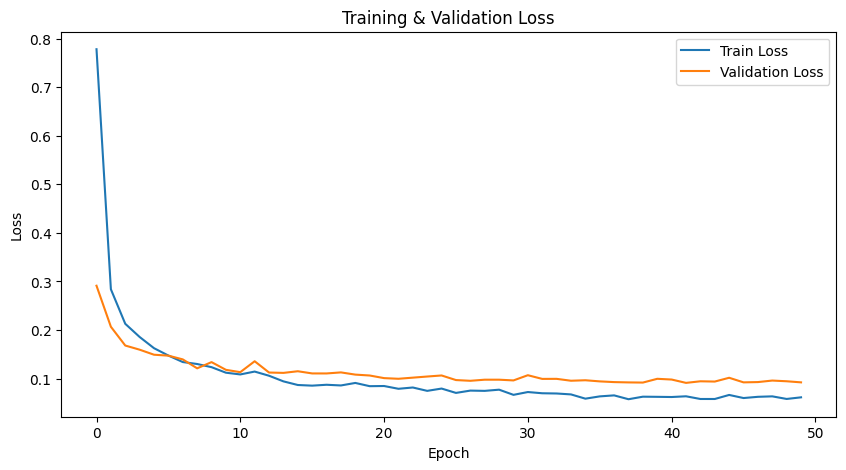

Evaluating: 100%|███████████████████████████████| 22/22 [00:04<00:00,  5.07it/s]



📊 Evaluation Metrics:
MAE: 4.63
MSE: 137.24
RMSE: 11.71
R² Score: 0.79
MAPE: inf%


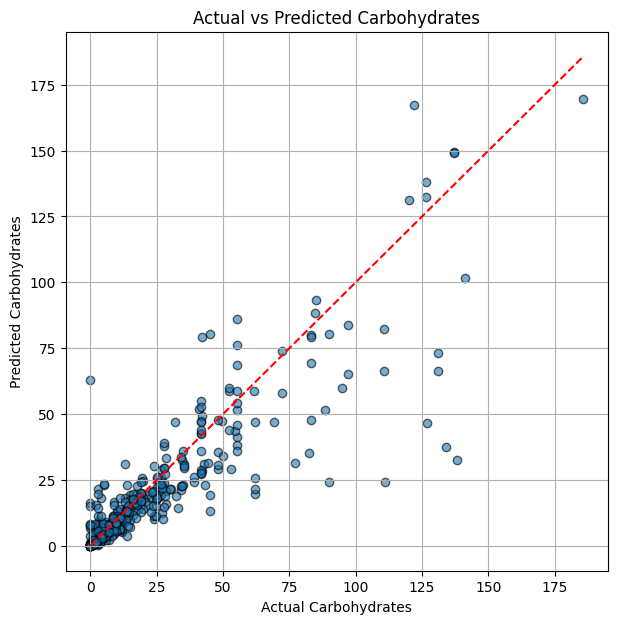

In [169]:
# EfficientNet model
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ---------------------------
# 1. Dataset
# ---------------------------
class CarbDataset(Dataset):
    def __init__(self, df, transform=None, is_train=True, scaler=None):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train
        self.transform = transform or self._default_transform(is_train)

        # Label encoding and feature scaling
        self.labels = LabelEncoder().fit_transform(df['label'])
        self.features, self.scaler = self._preprocess_features(df, scaler)
        self.targets = self._preprocess_targets(df['carb'].values)

    def _default_transform(self, is_train):
        base_transform = [
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ]
        if is_train:
            base_transform.insert(1, transforms.RandomHorizontalFlip())
            base_transform.insert(1, transforms.ColorJitter(0.2, 0.2, 0.2))
        return transforms.Compose(base_transform)

    def _preprocess_features(self, df, scaler=None):
        features = np.column_stack([
            self.labels,
            df['area'].values,
            df['aspect_ratio'].values,
            df['avg_intensity'].values
        ])

        if self.is_train:
            scaler = StandardScaler()
            features = scaler.fit_transform(features)
            return features, scaler
        else:
            if scaler is None:
                raise ValueError("Scaler must be provided for validation/test data")
            features = scaler.transform(features)
            return features, scaler

    def _preprocess_targets(self, targets):
        return np.log1p(targets)  # Log transform for regression

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.df.iloc[idx]['crop_path']).convert("RGB")
            image = self.transform(image)
        except Exception as e:
            print(f"Error loading image: {e}")
            image = torch.zeros(3, 256, 256)  # Fallback shape

        features = torch.tensor(self.features[idx], dtype=torch.float32)
        target = torch.tensor(self.targets[idx], dtype=torch.float32)
        return image, features, target

# ---------------------------
# 2. Model
# ---------------------------
class CarbEstimator(nn.Module):
    def __init__(self, num_classes, num_extra_features=4):
        super().__init__()
        backbone = models.efficientnet_b0(pretrained=True)
        self.backbone = nn.Sequential(
            *list(backbone.children())[:-2],
            nn.AdaptiveAvgPool2d(1)
        )
        self.feature_dim = 1280

        self.extra_feature_processor = nn.Sequential(
            nn.Linear(num_extra_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim + 64, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, extra_features):
        img_features = self.backbone(image).flatten(1)
        processed_features = self.extra_feature_processor(extra_features)
        combined = torch.cat([img_features, processed_features], dim=1)
        carb_pred = self.regressor(combined).squeeze()
        return carb_pred

# ---------------------------
# 3. Training Functions
# ---------------------------
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, features, targets in tqdm(train_loader, desc="Training"):
        images, features, targets = images.to(device), features.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images, features)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, features, targets in tqdm(val_loader, desc="Validating"):
            images, features, targets = images.to(device), features.to(device), targets.to(device)
            outputs = model(images, features)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
    return total_loss / len(val_loader)

# ---------------------------
# 4. Evaluation Function
# ---------------------------
def evaluate_predictions(model, val_loader, device):
    model.eval()
    predictions = []
    true_values = []

    with torch.no_grad():
        for images, features, targets in tqdm(val_loader, desc="Evaluating"):
            images, features = images.to(device), features.to(device)
            outputs = model(images, features).cpu().numpy()
            targets = targets.cpu().numpy()

            predictions.extend(outputs)
            true_values.extend(targets)

    predictions = np.expm1(predictions)
    true_values = np.expm1(true_values)

    mae = mean_absolute_error(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    r2 = r2_score(true_values, predictions)
    mse = mean_squared_error(true_values, predictions)
    mape = np.mean(np.abs((true_values - predictions) / true_values)) * 100

    print(f"\n📊 Evaluation Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print(f"MAPE: {mape:.2f}%") 

    # Plot actual vs predicted
    plt.figure(figsize=(7, 7))
    plt.scatter(true_values, predictions, alpha=0.6, edgecolors='k')
    plt.plot([min(true_values), max(true_values)],
             [min(true_values), max(true_values)], 'r--')
    plt.xlabel('Actual Carbohydrates')
    plt.ylabel('Predicted Carbohydrates')
    plt.title('Actual vs Predicted Carbohydrates')
    plt.grid(True)
    plt.savefig("actual_vs_predicted.png")
    plt.show()

# ---------------------------
# 5. Main
# ---------------------------
def main():
    # Load and split dataset
    dataset = pd.read_csv("/home/aojwang/data/model/model/CarboAI/debug_dataset.csv")
    train_df, val_df = train_test_split(
        dataset,
        test_size=0.2,
        random_state=42,
        stratify=pd.qcut(dataset['carb'], q=5)
    )

    # Prepare datasets
    train_ds = CarbDataset(train_df, is_train=True)
    val_ds = CarbDataset(val_df.reset_index(drop=True), is_train=False, scaler=train_ds.scaler)

    # Prepare loaders
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=32, num_workers=4, pin_memory=True)

    # Setup model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CarbEstimator(num_classes=len(np.unique(dataset['label'])))
    model.to(device)

    # Loss and optimizer
    criterion = nn.HuberLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

    # Training loop
    best_val_loss = float('inf')
    train_losses, val_losses = [], []

    for epoch in range(50):
        print(f"\nEpoch {epoch + 1}/50")
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print("✅ Saved best model.")

    # Plot training curves
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.savefig('training_curve.png')
    plt.show()

    return model, val_loader, device

# ---------------------------
# 6. Entry Point
# ---------------------------
if __name__ == "__main__":
    trained_model, val_loader, device = main()

    # Reload best model for evaluation
    trained_model.load_state_dict(torch.load('best_model.pth'))
    evaluate_predictions(trained_model, val_loader, device)



📅 Epoch 1/50


Validating: 100%|███████████████████████████████| 22/22 [00:09<00:00,  2.32it/s]


Train Loss: 0.8589 | Val Loss: 0.3301
✅ Best model saved.

📅 Epoch 2/50


Validating: 100%|███████████████████████████████| 22/22 [00:08<00:00,  2.48it/s]


Train Loss: 0.3381 | Val Loss: 0.2257
✅ Best model saved.

📅 Epoch 3/50


...

Train Loss: 0.0836 | Val Loss: 0.1058

📅 Epoch 49/50


Validating: 100%|███████████████████████████████| 22/22 [00:08<00:00,  2.51it/s]


Train Loss: 0.0774 | Val Loss: 0.1069

📅 Epoch 50/50


Validating: 100%|███████████████████████████████| 22/22 [00:08<00:00,  2.51it/s]


Train Loss: 0.0810 | Val Loss: 0.1075


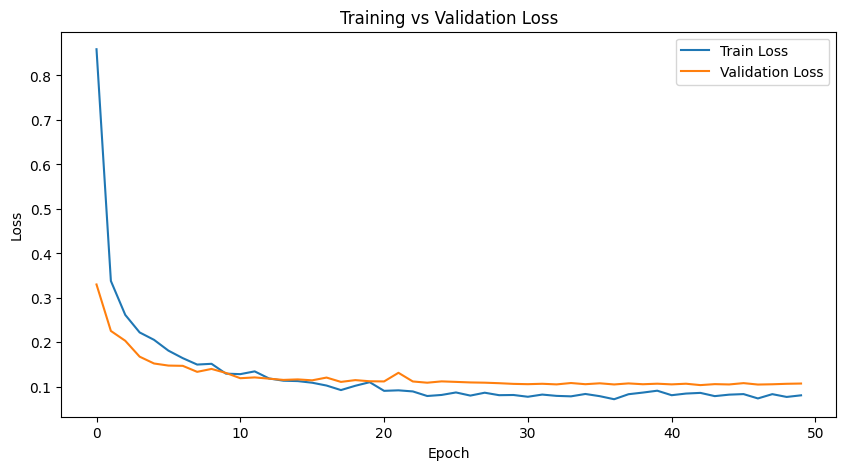

Evaluating: 100%|███████████████████████████████| 22/22 [00:08<00:00,  2.53it/s]



📊 Evaluation Metrics:
MAE: 5.23
MSE: 181.84
RMSE: 13.48
R² Score: 0.72
MAPE: 36691848.00%


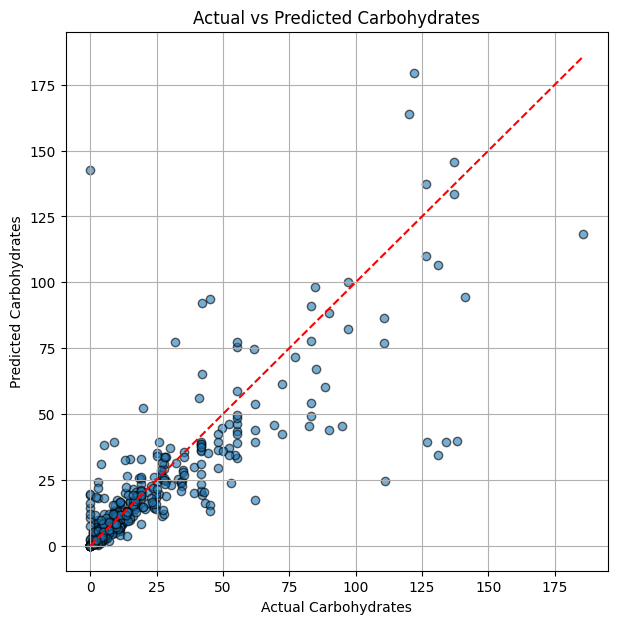

In [173]:
# EfficientNet model with augmentations
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# ---------------------------
# 1. Model Definition
# ---------------------------
class CarbEstimator(nn.Module):
    def __init__(self, num_extra_features=3):  # tabular features: area, aspect_ratio, avg_intensity
        super().__init__()
        backbone = models.efficientnet_b0(pretrained=True)
        self.backbone = nn.Sequential(
            *list(backbone.children())[:-2],  # remove classifier head
            nn.AdaptiveAvgPool2d(1)
        )
        self.feature_dim = 1280

        self.extra_feature_processor = nn.Sequential(
            nn.Linear(num_extra_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim + 64, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, extra_features):
        img_features = self.backbone(image).flatten(1)
        tabular_features = self.extra_feature_processor(extra_features)
        x = torch.cat([img_features, tabular_features], dim=1)
        return self.regressor(x).squeeze()

# ---------------------------
# 2. Training Functions
# ---------------------------
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in tqdm(dataloader, desc="Training"):
        image = batch["image"].to(device)
        tabular = batch["tabular"].to(device)
        target = torch.log1p(batch["target"]).to(device)  # log1p

        optimizer.zero_grad()
        output = model(image, tabular)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            image = batch["image"].to(device)
            tabular = batch["tabular"].to(device)
            target = torch.log1p(batch["target"]).to(device)  # log1p

            output = model(image, tabular)
            loss = criterion(output, target)
            total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_predictions(model, dataloader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            image = batch["image"].to(device)
            tabular = batch["tabular"].to(device)
            target = batch["target"].cpu().numpy()

            output = model(image, tabular).cpu().numpy()
            preds.extend(np.expm1(output))  # inverse of log1p
            trues.extend(target)

    preds = np.array(preds)
    trues = np.array(trues)

    mae = mean_absolute_error(trues, preds)
    mse = mean_squared_error(trues, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(trues, preds)
    mape = np.mean(np.abs((trues - preds) / np.clip(trues, 1e-6, None))) * 100

    print(f"\n📊 Evaluation Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # Plot actual vs predicted
    plt.figure(figsize=(7, 7))
    plt.scatter(trues, preds, alpha=0.6, edgecolors='k')
    plt.plot([min(trues), max(trues)], [min(trues), max(trues)], 'r--')
    plt.xlabel('Actual Carbohydrates')
    plt.ylabel('Predicted Carbohydrates')
    plt.title('Actual vs Predicted Carbohydrates')
    plt.grid(True)
    plt.savefig("actual_vs_predicted.png")
    plt.show()

# ---------------------------
# 3. Main Training Routine
# ---------------------------
def run_training():
    # Load CSV
    df = pd.read_csv("/home/aojwang/data/model/model/CarboAI/debug_dataset.csv")

    # Fit encoders BEFORE splitting
    label_encoder = LabelEncoder()
    label_encoder.fit(df["label"])
    df["label_encoded"] = label_encoder.transform(df["label"])  # Use new column

    scaler = StandardScaler()
    df[["area", "aspect_ratio", "avg_intensity"]] = scaler.fit_transform(
        df[["area", "aspect_ratio", "avg_intensity"]])

    # Split (use encoded label for stratification to avoid unseen labels)
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=pd.qcut(df["carb"], q=5)
    )

    # Dataset expects `label` column to be string — so fix:
    train_df["label"] = label_encoder.inverse_transform(train_df["label_encoded"])
    val_df["label"] = label_encoder.inverse_transform(val_df["label_encoded"])

    # Datasets
    train_ds = FoodRegressionDataset(train_df, augment=True, scaler=scaler, label_encoder=label_encoder)
    val_ds = FoodRegressionDataset(val_df.reset_index(drop=True), augment=False, scaler=scaler, label_encoder=label_encoder)

    # Loaders
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

    # Model setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CarbEstimator()
    model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    criterion = nn.HuberLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3)

    # Training loop
    best_val_loss = float("inf")
    train_losses, val_losses = [], []

    for epoch in range(50):
        print(f"\n📅 Epoch {epoch + 1}/50")
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "aug_efficientnet_b0.pth")
            print("✅ Best model saved.")

    # Plot loss curves
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.savefig("training_curve.png")
    plt.show()

    return model, val_loader, device

# ---------------------------
# 4. Run Everything
# ---------------------------
model, val_loader, device = run_training()
model.load_state_dict(torch.load("aug_efficientnet_b0.pth"))
evaluate_predictions(model, val_loader, device)



Epoch 1/50


Validating: 100%|███████████████████████████████| 19/19 [00:04<00:00,  4.69it/s]


Train Loss: 0.6418 | Val Loss: 0.2050
✅ Saved best model.

Epoch 2/50


Validating: 100%|███████████████████████████████| 19/19 [00:04<00:00,  4.65it/s]


Train Loss: 0.1969 | Val Loss: 0.1346
✅ Saved best model.

Epoch 3/50


...

Train Loss: 0.0516 | Val Loss: 0.0675

Epoch 49/50


Validating: 100%|███████████████████████████████| 19/19 [00:04<00:00,  4.63it/s]


Train Loss: 0.0524 | Val Loss: 0.0636

Epoch 50/50


Validating: 100%|███████████████████████████████| 19/19 [00:04<00:00,  4.72it/s]


Train Loss: 0.0498 | Val Loss: 0.0669


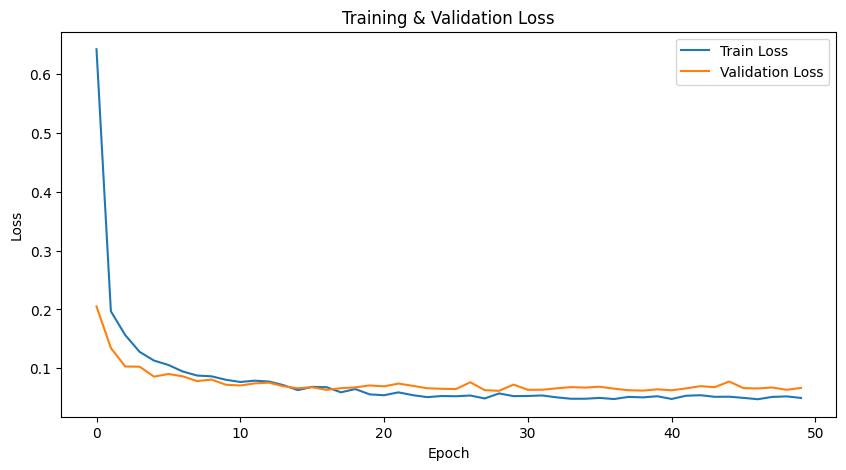

Evaluating: 100%|███████████████████████████████| 19/19 [00:04<00:00,  4.66it/s]



📊 Evaluation Metrics:
MAE: 2.70
MSE: 34.03
RMSE: 5.83
R² Score: 0.71
MAPE: 40.12%


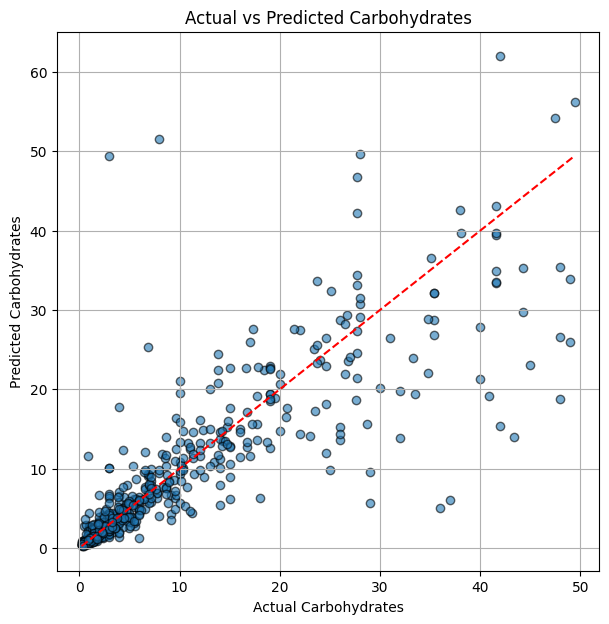

In [146]:
# EfficientNet model with capped carbohydrate content (0-50g
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

torch.manual_seed(42)
np.random.seed(42)

# ---------------------------
# 1. Dataset
# ---------------------------
class CarbDataset(Dataset):
    def __init__(self, df, transform=None, is_train=True, scaler=None):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train
        self.transform = transform or self._default_transform(is_train)

        self.labels = LabelEncoder().fit_transform(df['label'])
        self.features, self.scaler = self._preprocess_features(df, scaler)
        self.targets = self._preprocess_targets(df['carb'].values)

    def _default_transform(self, is_train):
        base_transform = [
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ]
        if is_train: #Images augmented during training: should use translation and flipping/rotation
            base_transform.insert(1, transforms.RandomHorizontalFlip())
            base_transform.insert(1, transforms.ColorJitter(0.2, 0.2, 0.2))
        return transforms.Compose(base_transform)

    def _preprocess_features(self, df, scaler=None):
        features = np.column_stack([
            self.labels,
            df['area'].values,
            df['aspect_ratio'].values,
            df['avg_intensity'].values
        ])
        if self.is_train:
            scaler = StandardScaler()
            features = scaler.fit_transform(features)
            return features, scaler
        else:
            if scaler is None:
                raise ValueError("Scaler must be provided for validation/test data")
            features = scaler.transform(features)
            return features, scaler

    def _preprocess_targets(self, targets):
        return np.log1p(targets)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.df.iloc[idx]['crop_path']).convert("RGB")
            image = self.transform(image)
        except Exception as e:
            print(f"Error loading image: {e}")
            image = torch.zeros(3, 256, 256)

        features = torch.tensor(self.features[idx], dtype=torch.float32)
        target = torch.tensor(self.targets[idx], dtype=torch.float32)
        return image, features, target

# ---------------------------
# 2. Model
# ---------------------------
class CarbEstimator(nn.Module):
    def __init__(self, num_classes, num_extra_features=4):
        super().__init__()
        backbone = models.efficientnet_b0(pretrained=True)
        self.backbone = nn.Sequential(
            *list(backbone.children())[:-2],
            nn.AdaptiveAvgPool2d(1)
        )
        self.feature_dim = 1280

        self.extra_feature_processor = nn.Sequential(
            nn.Linear(num_extra_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim + 64, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, extra_features):
        img_features = self.backbone(image).flatten(1)
        processed_features = self.extra_feature_processor(extra_features)
        combined = torch.cat([img_features, processed_features], dim=1)
        carb_pred = self.regressor(combined).squeeze()
        return carb_pred

# ---------------------------
# 3. Training Functions
# ---------------------------
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, features, targets in tqdm(train_loader, desc="Training"):
        images, features, targets = images.to(device), features.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images, features)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, features, targets in tqdm(val_loader, desc="Validating"):
            images, features, targets = images.to(device), features.to(device), targets.to(device)
            outputs = model(images, features)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
    return total_loss / len(val_loader)

# ---------------------------
# 4. Evaluation Function
# ---------------------------
def evaluate_predictions(model, val_loader, device):
    model.eval()
    predictions = []
    true_values = []

    with torch.no_grad():
        for images, features, targets in tqdm(val_loader, desc="Evaluating"):
            images, features = images.to(device), features.to(device)
            outputs = model(images, features).cpu().numpy()
            targets = targets.cpu().numpy()

            predictions.extend(outputs)
            true_values.extend(targets)

    predictions = np.expm1(predictions)
    true_values = np.expm1(true_values)

    # Filter zero true values to avoid division by zero in MAPE
    mask = true_values > 0
    predictions = predictions[mask]
    true_values = true_values[mask]

    mae = mean_absolute_error(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    r2 = r2_score(true_values, predictions)
    mse = mean_squared_error(true_values, predictions)
    mape = np.mean(np.abs((true_values - predictions) / true_values)) * 100

    print(f"\n📊 Evaluation Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print(f"MAPE: {mape:.2f}%") 

    plt.figure(figsize=(7, 7))
    plt.scatter(true_values, predictions, alpha=0.6, edgecolors='k')
    plt.plot([min(true_values), max(true_values)],
             [min(true_values), max(true_values)], 'r--')
    plt.xlabel('Actual Carbohydrates')
    plt.ylabel('Predicted Carbohydrates')
    plt.title('Actual vs Predicted Carbohydrates')
    plt.grid(True)
    plt.savefig("actual_vs_predicted.png")
    plt.show()

# ---------------------------
# 5. Main
# ---------------------------
def main():
    dataset = pd.read_csv("/home/aojwang/data/model/model/CarboAI/debug_dataset.csv")

    # ✅ CAP: Only keep carb values in (0, 50]
    dataset = dataset[(dataset['carb'] > 0) & (dataset['carb'] <= 50)].copy()
    dataset.reset_index(drop=True, inplace=True)

    train_df, val_df = train_test_split(
        dataset,
        test_size=0.2,
        random_state=42,
        stratify=pd.qcut(dataset['carb'], q=5)
    )

    train_ds = CarbDataset(train_df, is_train=True)
    val_ds = CarbDataset(val_df.reset_index(drop=True), is_train=False, scaler=train_ds.scaler)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=32, num_workers=4, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CarbEstimator(num_classes=len(np.unique(dataset['label'])))
    model.to(device)

    criterion = nn.HuberLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

    best_val_loss = float('inf')
    train_losses, val_losses = [], []

    for epoch in range(50):
        print(f"\nEpoch {epoch + 1}/50")
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print("✅ Saved best model.")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.savefig('training_curve.png')
    plt.show()

    return model, val_loader, device

# ---------------------------
# 6. Entry Point
# ---------------------------
if __name__ == "__main__":
    trained_model, val_loader, device = main()
    trained_model.load_state_dict(torch.load('best_model.pth'))
    evaluate_predictions(trained_model, val_loader, device)


In [9]:
import pandas as pd

df =  pd.read_csv('refined_dataset.csv')
target_col = 'carb'
df.columns
print("Target variable statistics:")
print(df[target_col].describe())
print(f"\nNumber of zero values: {(df[target_col] == 0).sum()}")
print(f"Negative values: {(df[target_col] < 0).sum()}")

Target variable statistics:
count    3402.000000
mean       15.028532
std        25.774474
min         0.000000
25%         1.500000
50%         4.305000
75%        15.600000
max       185.830000
Name: carb, dtype: float64

Number of zero values: 113
Negative values: 0



📅 Epoch 1/50


Validating: 100%|███████████████████████████████| 19/19 [00:08<00:00,  2.24it/s]


Train Loss: 0.5012 | Val Loss: 0.1780
✅ Best model saved.

📅 Epoch 2/50


Validating: 100%|███████████████████████████████| 19/19 [00:08<00:00,  2.23it/s]


Train Loss: 0.2143 | Val Loss: 0.1478
✅ Best model saved.

📅 Epoch 3/50


...

Train Loss: 0.0768 | Val Loss: 0.0714

📅 Epoch 49/50


Validating: 100%|███████████████████████████████| 19/19 [00:08<00:00,  2.22it/s]


Train Loss: 0.0775 | Val Loss: 0.0711

📅 Epoch 50/50


Validating: 100%|███████████████████████████████| 19/19 [00:08<00:00,  2.25it/s]

Train Loss: 0.0696 | Val Loss: 0.0776


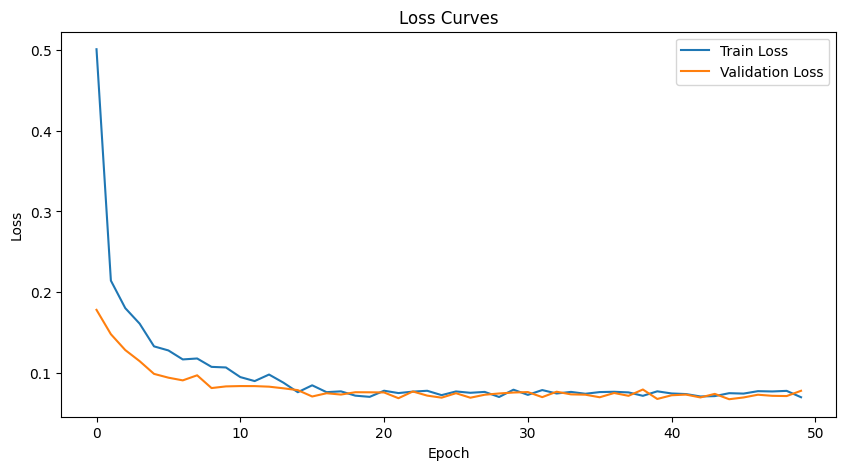

Evaluating: 100%|███████████████████████████████| 19/19 [00:08<00:00,  2.23it/s]



📊 Evaluation Metrics:
MAE: 2.94
MSE: 43.98
RMSE: 6.63
R² Score: 0.63
MAPE: 39.13%


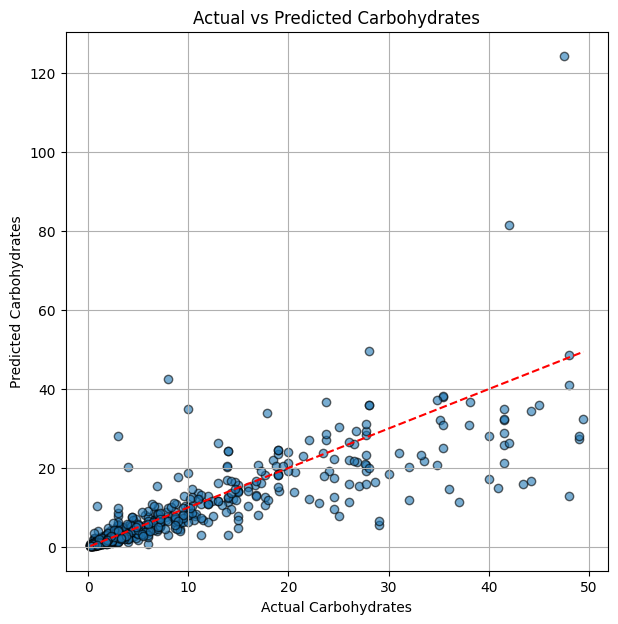

In [177]:
# EfficientNet Model for Carbohydrate Estimation + Augmentation + Carb content cap 0-50g

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------
# 1. Model Definition
# ---------------------------
class CarbEstimator(nn.Module):
    def __init__(self, num_classes, num_extra_features=3):
        super().__init__()
        backbone = models.efficientnet_b0(pretrained=True)
        self.backbone = nn.Sequential(
            *list(backbone.children())[:-2],
            nn.AdaptiveAvgPool2d(1)
        )
        self.feature_dim = 1280

        self.extra_feature_processor = nn.Sequential(
            nn.Linear(num_extra_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim + 64, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, extra_features):
        img_features = self.backbone(image).flatten(1)
        processed_features = self.extra_feature_processor(extra_features)
        combined = torch.cat([img_features, processed_features], dim=1)
        carb_pred = self.regressor(combined).squeeze()
        return carb_pred

# ---------------------------
# 2. Training & Validation
# ---------------------------
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Training"):
        image, tabular, target = batch["image"], batch["tabular"], batch["target"]
        image, tabular, target = image.to(device), tabular.to(device), target.to(device)

        optimizer.zero_grad()
        pred = model(image, tabular)
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validating"):
            image, tabular, target = batch["image"], batch["tabular"], batch["target"]
            image, tabular, target = image.to(device), tabular.to(device), target.to(device)
            pred = model(image, tabular)
            loss = criterion(pred, target)
            total_loss += loss.item()
    return total_loss / len(loader)

# ---------------------------
# 3. Evaluation
# ---------------------------
def evaluate_predictions(model, loader, device):
    model.eval()
    predictions, targets = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            image, tabular = batch["image"].to(device), batch["tabular"].to(device)
            target = batch["target"].cpu().numpy()
            pred = model(image, tabular).cpu().numpy()

            predictions.extend(pred)
            targets.extend(target)

    predictions = np.expm1(predictions)
    targets = np.expm1(targets)

    mask = targets > 0
    targets, predictions = np.array(targets)[mask], np.array(predictions)[mask]

    mae = mean_absolute_error(targets, predictions)
    mse = mean_squared_error(targets, predictions)
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    mape = np.mean(np.abs((targets - predictions) / targets)) * 100

    print("\n📊 Evaluation Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print(f"MAPE: {mape:.2f}%")

    plt.figure(figsize=(7, 7))
    plt.scatter(targets, predictions, alpha=0.6, edgecolors='k')
    plt.plot([min(targets), max(targets)], [min(targets), max(targets)], 'r--')
    plt.xlabel('Actual Carbohydrates')
    plt.ylabel('Predicted Carbohydrates')
    plt.title('Actual vs Predicted Carbohydrates')
    plt.grid(True)
    plt.savefig("actual_vs_predicted.png")
    plt.show()

# ---------------------------
# 4. Main
# ---------------------------
def main():
    df = pd.read_csv("/home/aojwang/data/model/model/CarboAI/debug_dataset.csv")
    df = df[(df['carb'] > 0) & (df['carb'] <= 50)].copy().reset_index(drop=True)
    df['carb'] = np.log1p(df['carb'])

    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        stratify=pd.qcut(df['carb'], 5, duplicates='drop'),
        random_state=42
    )

    label_encoder = LabelEncoder().fit(df["label"])
    scaler = StandardScaler().fit(train_df[["area", "aspect_ratio", "avg_intensity"]])

    train_ds = FoodRegressionDataset(train_df, transform=None, augment=True,
                                     scaler=scaler, label_encoder=label_encoder)
    val_ds = FoodRegressionDataset(val_df, transform=None, augment=False,
                                   scaler=scaler, label_encoder=label_encoder)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CarbEstimator(num_classes=len(label_encoder.classes_)).to(device)

    criterion = nn.HuberLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3)

    best_val_loss = float("inf")
    train_losses, val_losses = [], []

    for epoch in range(50):
        print(f"\n📅 Epoch {epoch + 1}/50")
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_efficientnet_model.pth")
            print("✅ Best model saved.")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title("Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig("training_curve.png")
    plt.show()

    return model, val_loader, device

# ---------------------------
# 5. Entry Point
# ---------------------------
if __name__ == "__main__":
    model, val_loader, device = main()
    model.load_state_dict(torch.load("best_efficientnet_model.pth", map_location=device))
    model.to(device)
    evaluate_predictions(model, val_loader, device)


/opt/dlami/nvme/aojwang/torchenv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/dlami/nvme/aojwang/torchenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 - Train Loss: 0.3759
Epoch 2 - Train Loss: 0.1908
Epoch 3 - Train Loss: 0.1003
Epoch 4 - Train Loss: 0.0764
Epoch 5 - Train Loss: 0.0455
Epoch 6 - Train Loss: 0.0334
Epoch 7 - Train Loss: 0.0166
Epoch 8 - Train Loss: 0.0103
Epoch 9 - Train Loss: 0.0096
Epoch 10 - Train Loss: 0.0070

📊 Final Evaluation:
MAE: 5.7861
MSE: 211.4033
R2 Score: 0.6960


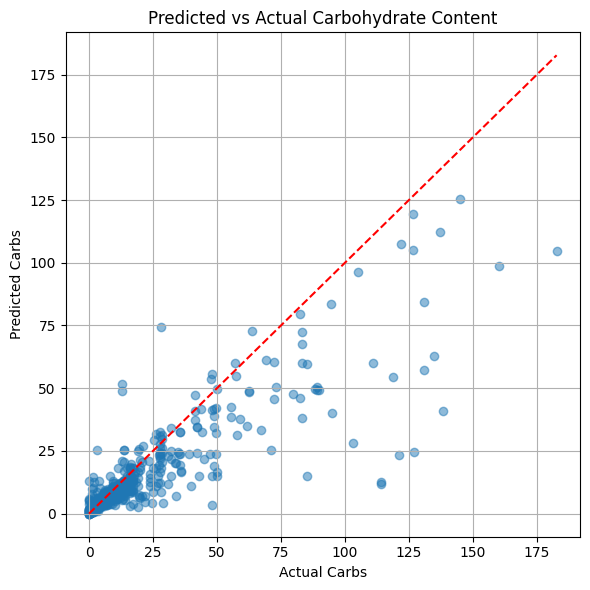

In [57]:
# ViT pretrained model
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset
import torch
from torchvision import transforms
import torch.nn as nn
from torchvision.models.vision_transformer import vit_b_16
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from PIL import Image
import joblib

# Load and preprocess
df = pd.read_csv("debug_dataset.csv")

# Log-transform the target
df['log_carb'] = np.log1p(df['carb'])

# Normalize tabular features
tabular_features = ['area', 'aspect_ratio', 'avg_intensity']
scaler = StandardScaler()
df[tabular_features] = scaler.fit_transform(df[tabular_features])

# Save scaler for later inverse-transform if needed
joblib.dump(scaler, "scaler.pkl")

# Dataset class
class FoodRegressionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['crop_path']).convert("RGB")
        image = self.transform(image)
        tabular = torch.tensor([row['area'], row['aspect_ratio'], row['avg_intensity']], dtype=torch.float32)
        target = torch.tensor(row['log_carb'], dtype=torch.float32)
        return image, tabular, target

class FoodViTRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = vit_b_16(pretrained=True)
        self.vit.heads = nn.Identity()
        self.tabular_net = nn.Sequential(
            nn.Linear(3, 16),
            nn.ReLU(),
            nn.Linear(16, 16)
        )
        self.fc = nn.Sequential(
            nn.Linear(768 + 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, img, tabular):
        img_feat = self.vit(img)
        tab_feat = self.tabular_net(tabular)
        combined = torch.cat((img_feat, tab_feat), dim=1)
        return self.fc(combined).squeeze(1)

# Data split
train_size = int(0.8 * len(df))
val_size = len(df) - train_size
train_df, val_df = random_split(df, [train_size, val_size])

train_dataset = FoodRegressionDataset(train_df.dataset.iloc[train_df.indices])
val_dataset = FoodRegressionDataset(val_df.dataset.iloc[val_df.indices])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Model
model = FoodViTRegressor().cuda()
criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Train loop
train_losses = []
for epoch in range(10):
    model.train()
    running_loss = 0
    for images, tabular, targets in train_loader:
        images, tabular, targets = images.cuda(), tabular.cuda(), targets.cuda()
        optimizer.zero_grad()
        outputs = model(images, tabular)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1} - Train Loss: {epoch_loss:.4f}")


# Evaluate on validation set
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, tabular, targets in val_loader:
        images, tabular = images.cuda(), tabular.cuda()
        outputs = model(images, tabular).cpu().numpy()
        targets = targets.cpu().numpy()
        y_pred.extend(outputs)
        y_true.extend(targets)

# Reverse log-transform
y_true_raw = np.expm1(y_true)
y_pred_raw = np.expm1(y_pred)

# Metrics
mae = mean_absolute_error(y_true_raw, y_pred_raw)
mse = mean_squared_error(y_true_raw, y_pred_raw)
r2 = r2_score(y_true_raw, y_pred_raw)

print(f"\n📊 Final Evaluation:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(y_true_raw, y_pred_raw, alpha=0.5)
plt.plot([min(y_true_raw), max(y_true_raw)], [min(y_true_raw), max(y_true_raw)], 'r--')
plt.xlabel("Actual Carbs")
plt.ylabel("Predicted Carbs")
plt.title("Predicted vs Actual Carbohydrate Content")
plt.grid(True)
plt.tight_layout()
plt.show()


Epoch 1 - Train Loss: 0.3876
Epoch 2 - Train Loss: 0.1997
Epoch 3 - Train Loss: 0.0813
Epoch 4 - Train Loss: 0.0586
Epoch 5 - Train Loss: 0.0397
Epoch 6 - Train Loss: 0.0253
Epoch 7 - Train Loss: 0.0235
Epoch 8 - Train Loss: 0.0141
Epoch 9 - Train Loss: 0.0090
Epoch 10 - Train Loss: 0.0112
MAE (Mean Absolute Error): 5.47536563873291
MSE (Mean Squared Error): 242.1638641357422
RMSE (Root Mean Squared Error): 15.561615087636058
R2 Score (Coefficient of Determination): 0.6350659132003784
MAPE (Mean Absolute Percentage Error): nan%


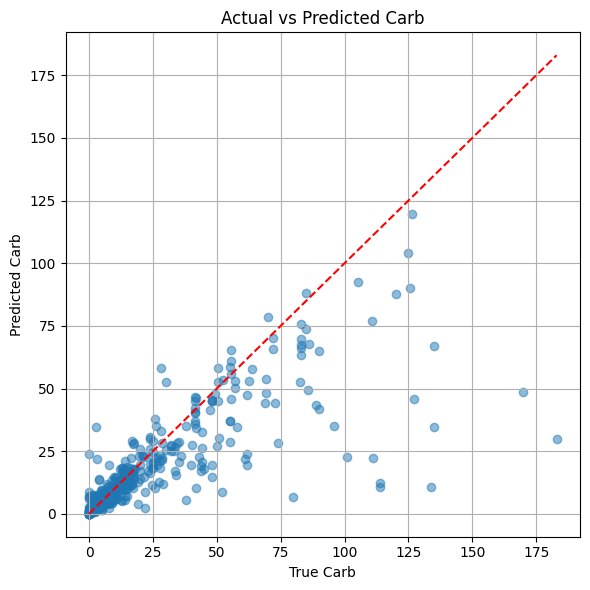

In [106]:
# Pretrained ViT model
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from timm import create_model

# === Dataset Class ===
class FoodDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_encoder = LabelEncoder()
        self.df['label_encoded'] = self.label_encoder.fit_transform(self.df['label'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['crop_path']).convert("RGB")
        if self.transform:
            image = self.transform(image)
        extra_features = torch.tensor([
            row['label_encoded'],
            row['area'],
            row['aspect_ratio'],
            row['avg_intensity']
        ], dtype=torch.float32)
        target = torch.tensor(row['carb_log'], dtype=torch.float32)  # Use log-transformed carb
        return image, extra_features, target

# === Model ===
class ViTRegressor(nn.Module):
    def __init__(self, vit_name='vit_base_patch16_224', extra_feat_dim=4):
        super().__init__()
        self.vit = create_model(vit_name, pretrained=True, num_classes=0)
        self.head = nn.Sequential(
            nn.Linear(self.vit.num_features + extra_feat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x_img, x_extra):
        x_vit = self.vit(x_img)
        x = torch.cat([x_vit, x_extra], dim=1)
        return self.head(x).squeeze(1)

# === Training Function ===
def train_one_epoch(model, dataloader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for x_img, x_extra, y in dataloader:
        x_img, x_extra, y = x_img.to(device), x_extra.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x_img, x_extra)
        pred = torch.clamp(pred, min=0, max=5.3)  # log(1 + 200) ~= 5.3
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

# === Evaluation Function ===
def evaluate(model, dataloader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x_img, x_extra, y in dataloader:
            x_img, x_extra = x_img.to(device), x_extra.to(device)
            pred = model(x_img, x_extra).cpu()
            pred = torch.clamp(pred, min=0, max=5.3)  # log scale
            y_true.extend(y.numpy())
            y_pred.extend(pred.numpy())
    y_true = np.expm1(y_true)  # inverse transform
    y_pred = np.expm1(y_pred)
    return y_true, y_pred

# === Visualization ===
def plot_regression_results(y_true, y_pred):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.xlabel("True Carb")
    plt.ylabel("Predicted Carb")
    plt.title("Actual vs Predicted Carb")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("regression_results.png")
    plt.show()

# === Main Script ===
if __name__ == "__main__":
    # Load and preprocess data
    df = pd.read_csv("debug_dataset.csv")

    # Normalize tabular features
    scaler = StandardScaler()
    df[['area', 'aspect_ratio', 'avg_intensity']] = scaler.fit_transform(
        df[['area', 'aspect_ratio', 'avg_intensity']]
    )

    # Log-transform carb values
    df['carb_log'] = np.log1p(df['carb'])

    # Train-test split
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

    # Transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    # Dataloaders
    train_loader = DataLoader(FoodDataset(train_df, transform), batch_size=32, shuffle=True)
    test_loader = DataLoader(FoodDataset(test_df, transform), batch_size=32)

    # Model setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ViTRegressor().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.SmoothL1Loss()

    # Training
    for epoch in range(10):
        loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
        print(f"Epoch {epoch + 1} - Train Loss: {loss:.4f}")

    # Evaluation
    y_true, y_pred = evaluate(model, test_loader)
    print("MAE (Mean Absolute Error):", mean_absolute_error(y_true, y_pred))
    print("MSE (Mean Squared Error):", mean_squared_error(y_true, y_pred))
    print("RMSE (Root Mean Squared Error):", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score (Coefficient of Determination):", r2_score(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print("MAPE (Mean Absolute Percentage Error): {:.2f}%".format(mape))

    # Plot
    plot_regression_results(y_true, y_pred)


Epoch 1/10 - Validation: 100%|██████████████████| 43/43 [00:16<00:00,  2.65it/s]


Epoch 1 - Train Loss: 0.4229 | Val Loss: 0.2696


Epoch 2/10 - Validation: 100%|██████████████████| 43/43 [00:16<00:00,  2.65it/s]


Epoch 2 - Train Loss: 0.2212 | Val Loss: 0.2325


Epoch 3/10 - Validation: 100%|██████████████████| 43/43 [00:16<00:00,  2.63it/s]


...

Epoch 8 - Train Loss: 0.0821 | Val Loss: 0.1572


Epoch 9/10 - Validation: 100%|██████████████████| 43/43 [00:16<00:00,  2.64it/s]


Epoch 9 - Train Loss: 0.0789 | Val Loss: 0.1517


Epoch 10/10 - Validation: 100%|█████████████████| 43/43 [00:16<00:00,  2.64it/s]


Epoch 10 - Train Loss: 0.0682 | Val Loss: 0.1393

📊 Evaluation Metrics:
MAE:  7.5335
MSE:  318.7928
RMSE: 17.8548
R²:   0.5196
MAPE: 55.42%


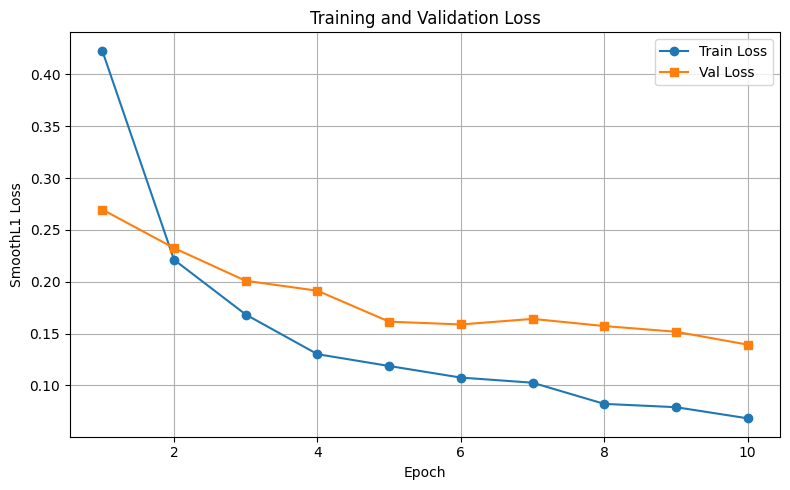

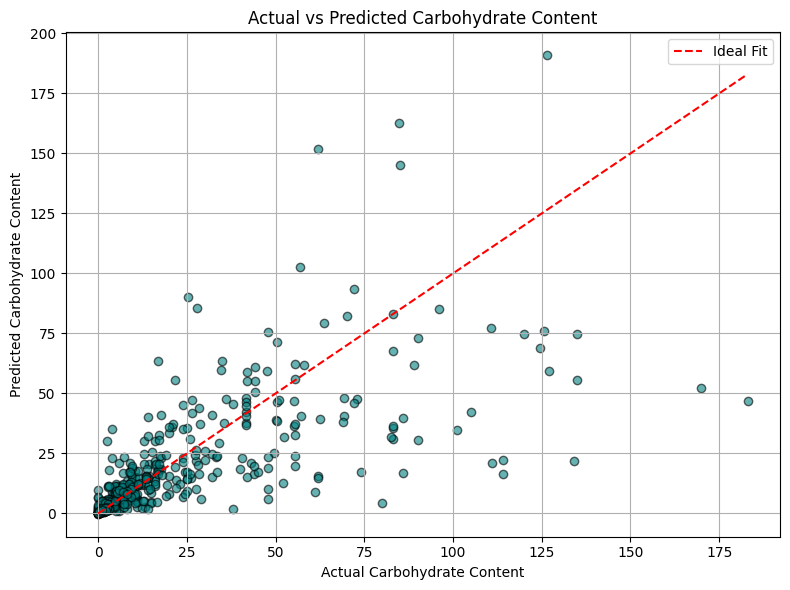

In [113]:
# efficientnet
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load dataset
df = pd.read_csv("/home/aojwang/data/model/model/CarboAI/debug_dataset.csv")

# Log-transform the target
df["log_carb"] = np.log1p(df["carb"])

# Normalize tabular features
scaler = StandardScaler()
tabular_features = ["area", "aspect_ratio", "avg_intensity"]
df[tabular_features] = scaler.fit_transform(df[tabular_features])

# Define image transforms
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset class
class FoodRegressionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform or transforms.ToTensor()

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = plt.imread(row["crop_path"])
        if len(image.shape) == 2:
            image = np.stack([image]*3, axis=-1)
        elif image.shape[2] == 4:
            image = image[:, :, :3]
        if self.transform:
            image = self.transform(image)
        tabular_feats = torch.tensor([
            row["area"], row["aspect_ratio"], row["avg_intensity"]
        ], dtype=torch.float32)
        target = torch.tensor(row["log_carb"], dtype=torch.float32)
        return image, tabular_feats, target

# Train/Val split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Dataloader helper
def create_dataloader_from_dataframe(df, transform, batch_size=16, shuffle=True):
    dataset = FoodRegressionDataset(df, transform=transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# Dataloaders
train_loader = create_dataloader_from_dataframe(train_df, transform=transform)
val_loader = create_dataloader_from_dataframe(val_df, transform=transform, shuffle=False)

# Model class
class EfficientNetRegressor(nn.Module):
    def __init__(self, tabular_dim):
        super().__init__()
        self.backbone = models.efficientnet_b0(pretrained=True)
        self.backbone.classifier = nn.Identity()
        self.fc = nn.Sequential(
            nn.Linear(1280 + tabular_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )

    def forward(self, image, tabular):
        img_feat = self.backbone(image)
        x = torch.cat([img_feat, tabular], dim=1)
        return self.fc(x)

# Instantiate model
model = EfficientNetRegressor(tabular_dim=3).to(device)

# Loss and optimizer
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
EPOCHS = 10
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_epoch_loss = 0
    for images, tabular, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training"):
        images, tabular, targets = images.to(device), tabular.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(images, tabular).squeeze()
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_epoch_loss += loss.item() * images.size(0)
    avg_train_loss = train_epoch_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    val_epoch_loss = 0
    with torch.no_grad():
        for images, tabular, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Validation"):
            images, tabular, targets = images.to(device), tabular.to(device), targets.to(device)
            outputs = model(images, tabular).squeeze()
            loss = criterion(outputs, targets)
            val_epoch_loss += loss.item() * images.size(0)
    avg_val_loss = val_epoch_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, tabular, targets in val_loader:
        images, tabular = images.to(device), tabular.to(device)
        outputs = model(images, tabular).squeeze().cpu().numpy()
        y_pred.extend(outputs)
        y_true.extend(targets.numpy())

# Inverse log transform
y_pred = np.expm1(y_pred)
y_true = np.expm1(y_true)

# Evaluation metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape = safe_mape(y_true, y_pred)

print("\n📊 Evaluation Metrics:")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, marker='s', label="Val Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1 Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.6, color='teal', edgecolors='k')
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', label='Ideal Fit')
plt.xlabel("Actual Carbohydrate Content")
plt.ylabel("Predicted Carbohydrate Content")
plt.title("Actual vs Predicted Carbohydrate Content")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Epoch 1/10 - Train Loss: 0.4472 - Val Loss: 0.2013
Epoch 2/10 - Train Loss: 0.1413 - Val Loss: 0.1639
Epoch 3/10 - Train Loss: 0.0883 - Val Loss: 0.1714
Epoch 4/10 - Train Loss: 0.0684 - Val Loss: 0.1437
Epoch 5/10 - Train Loss: 0.0551 - Val Loss: 0.1456
Epoch 6/10 - Train Loss: 0.0411 - Val Loss: 0.1397
Epoch 7/10 - Train Loss: 0.0409 - Val Loss: 0.1348
Epoch 8/10 - Train Loss: 0.0435 - Val Loss: 0.1322
Epoch 9/10 - Train Loss: 0.0299 - Val Loss: 0.1288
Epoch 10/10 - Train Loss: 0.0267 - Val Loss: 0.1268


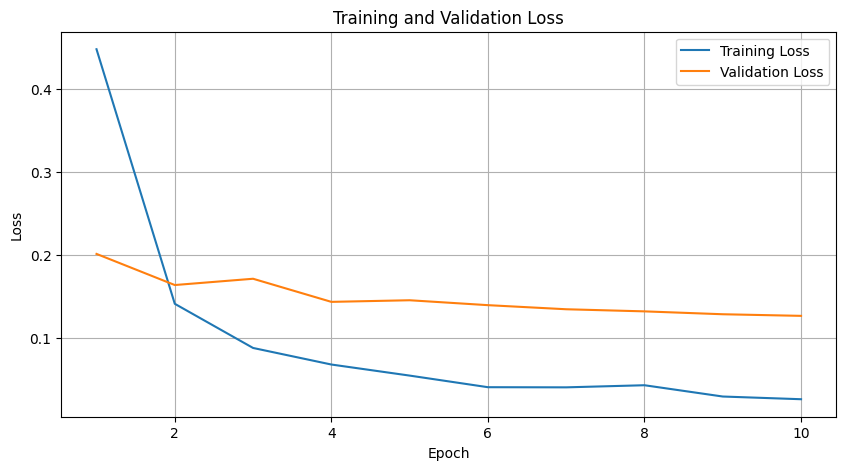


📊 Evaluation Metrics on Test Set:
MAE: 6.8944
MSE: 339.3809
RMSE: 18.4223
R2 Score: 0.4886
MAPE: 188950200320.00%


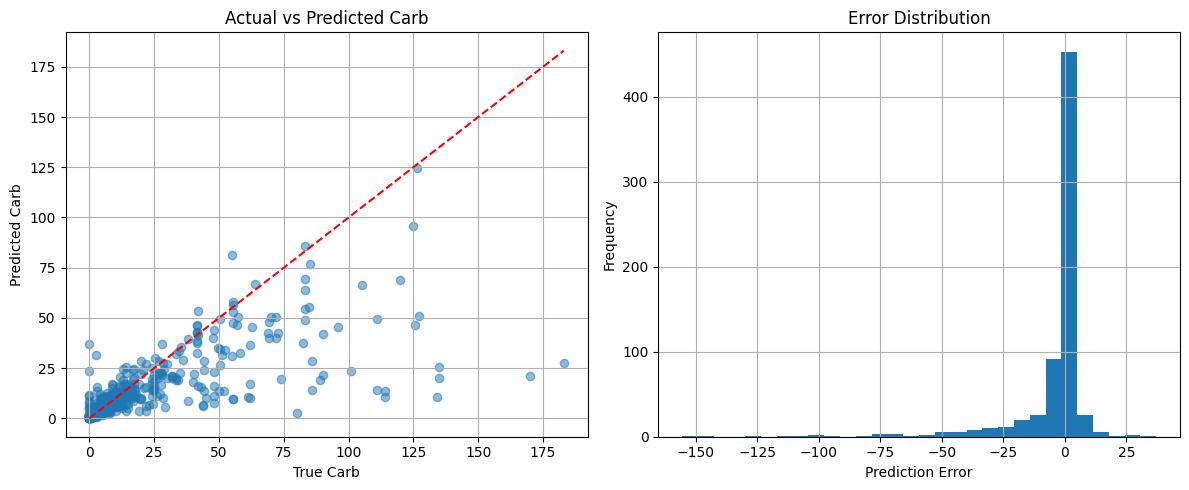

In [116]:
# using a pretrained ResNet-18 CNN model
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from PIL import Image
import matplotlib.pyplot as plt

# ==== Configuration ====
CSV_PATH = "/home/aojwang/data/model/model/CarboAI/debug_dataset.csv"
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==== Load and preprocess data ====
df = pd.read_csv(CSV_PATH)
df["carb_log"] = np.log1p(df["carb"])
scaler = StandardScaler()
df[["area", "aspect_ratio", "avg_intensity"]] = scaler.fit_transform(df[["area", "aspect_ratio", "avg_intensity"]])

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

# ==== Dataset and DataLoader ====
class FoodRegressionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["crop_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)

        tabular_feats = torch.tensor([
            row["area"], row["aspect_ratio"], row["avg_intensity"]
        ], dtype=torch.float32)

        target = torch.tensor(row["carb_log"], dtype=torch.float32)
        return image, tabular_feats, target

def create_dataloader(df, batch_size=32, shuffle=True):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3)
    ])
    dataset = FoodRegressionDataset(df, transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = create_dataloader(train_df, BATCH_SIZE, True)
val_loader = create_dataloader(val_df, BATCH_SIZE, False)
test_loader = create_dataloader(test_df, BATCH_SIZE, False)

# ==== Model ====
class CarboPredictor(nn.Module):
    def __init__(self, tabular_dim=3):
        super(CarboPredictor, self).__init__()
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Identity()
        self.tabular_layer = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(512 + 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular):
        img_feat = self.cnn(image)
        tab_feat = self.tabular_layer(tabular)
        combined = torch.cat((img_feat, tab_feat), dim=1)
        out = self.fc(combined).squeeze(1)
        return torch.clamp(out, min=0.0, max=5.3)  # log1p(200) ~ 5.3

model = CarboPredictor().to(DEVICE)
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ==== Training and Evaluation ====
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for images, tabular, targets in loader:
        images, tabular, targets = images.to(DEVICE), tabular.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        preds = model(images, tabular)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, tabular, targets in loader:
            images, tabular, targets = images.to(DEVICE), tabular.to(DEVICE), targets.to(DEVICE)
            preds = model(images, tabular)
            loss = criterion(preds, targets)
            total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate_metrics(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for images, tabular, labels in loader:
            images, tabular = images.to(DEVICE), tabular.to(DEVICE)
            outputs = model(images, tabular).cpu().numpy()
            preds.extend(outputs)
            targets.extend(labels.numpy())
    
    # Convert from log scale back to original
    preds = np.expm1(np.clip(preds, 0, None))
    targets = np.expm1(targets)
    
    # Calculate metrics
    mae = mean_absolute_error(targets, preds)
    mse = mean_squared_error(targets, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(targets, preds)
    
    # Calculate MAPE (Mean Absolute Percentage Error)
    epsilon = 1e-10  # small constant to avoid division by zero
    mape = np.mean(np.abs((targets - preds) / (targets + epsilon))) * 100
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape,
        'predictions': preds,
        'targets': targets
    }

# ==== Training Loop ====
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate_loss(model, val_loader)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch + 1}/{EPOCHS} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss')
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig("training_validation_loss.png")
plt.show()

# ==== Final Evaluation ====
test_metrics = evaluate_metrics(model, test_loader)

print("\n📊 Evaluation Metrics on Test Set:")
print(f"MAE: {test_metrics['MAE']:.4f}")
print(f"MSE: {test_metrics['MSE']:.4f}")
print(f"RMSE: {test_metrics['RMSE']:.4f}")
print(f"R2 Score: {test_metrics['R2']:.4f}")
print(f"MAPE: {test_metrics['MAPE']:.2f}%")

# ==== Visualization ====
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(test_metrics['targets'], test_metrics['predictions'], alpha=0.5)
plt.plot([0, max(test_metrics['targets'])], [0, max(test_metrics['targets'])], 'r--')
plt.xlabel("True Carb")
plt.ylabel("Predicted Carb")
plt.title("Actual vs Predicted Carb")
plt.grid(True)

# Plot 2: Error distribution
plt.subplot(1, 2, 2)
errors = test_metrics['predictions'] - test_metrics['targets']
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.grid(True)

plt.tight_layout()
plt.savefig("prediction_results.png")
plt.show()

Epoch 1/10 - Train Loss: 0.5399 - Val Loss: 0.3455 - LR: 1.00e-04
Epoch 2/10 - Train Loss: 0.2001 - Val Loss: 0.2159 - LR: 1.00e-04
Epoch 3/10 - Train Loss: 0.1207 - Val Loss: 0.1752 - LR: 1.00e-04
Epoch 4/10 - Train Loss: 0.0980 - Val Loss: 0.1763 - LR: 1.00e-04
Epoch 5/10 - Train Loss: 0.0836 - Val Loss: 0.1569 - LR: 1.00e-04
Epoch 6/10 - Train Loss: 0.0678 - Val Loss: 0.1458 - LR: 1.00e-04
Epoch 7/10 - Train Loss: 0.0571 - Val Loss: 0.1395 - LR: 1.00e-04
Epoch 8/10 - Train Loss: 0.0683 - Val Loss: 0.1456 - LR: 1.00e-04
Epoch 9/10 - Train Loss: 0.0567 - Val Loss: 0.1319 - LR: 1.00e-04

📊 Evaluation Metrics on Test Set:
MAE: 6.9164
MSE: 333.3856
RMSE: 18.2588
R2 Score: 0.4976
MAPE: 195444162560.00%


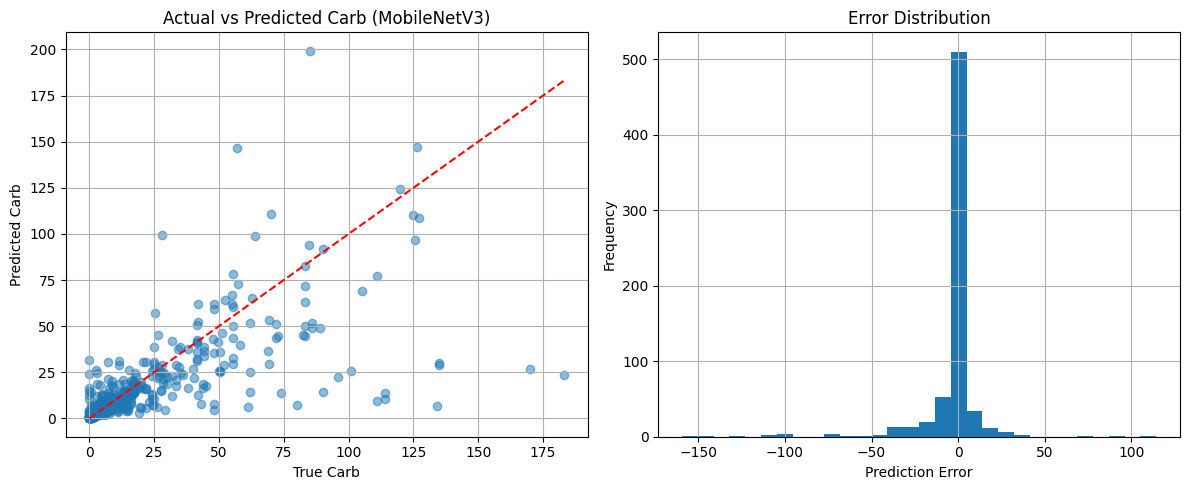

In [118]:
# using a pretrained MobileNetV3 CNN model
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from PIL import Image
import matplotlib.pyplot as plt

# ==== Configuration ====
CSV_PATH = "/home/aojwang/data/model/model/CarboAI/debug_dataset.csv"
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==== Load and preprocess data ====
df = pd.read_csv(CSV_PATH)
df["carb_log"] = np.log1p(df["carb"])
scaler = StandardScaler()
df[["area", "aspect_ratio", "avg_intensity"]] = scaler.fit_transform(df[["area", "aspect_ratio", "avg_intensity"]])

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

# ==== Dataset and DataLoader ====
class FoodRegressionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["crop_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)

        tabular_feats = torch.tensor([
            row["area"], row["aspect_ratio"], row["avg_intensity"]
        ], dtype=torch.float32)

        target = torch.tensor(row["carb_log"], dtype=torch.float32)
        return image, tabular_feats, target

def create_dataloader(df, batch_size=32, shuffle=True):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                             std=[0.229, 0.224, 0.225])  # MobileNetV3 normalization
    ])
    dataset = FoodRegressionDataset(df, transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = create_dataloader(train_df, BATCH_SIZE, True)
val_loader = create_dataloader(val_df, BATCH_SIZE, False)
test_loader = create_dataloader(test_df, BATCH_SIZE, False)

# ==== MobileNetV3 Model ====
class CarboPredictor(nn.Module):
    def __init__(self, tabular_dim=3):
        super(CarboPredictor, self).__init__()
        # Load pretrained MobileNetV3 large
        self.cnn = models.mobilenet_v3_large(pretrained=True)
        
        # Remove the classifier head
        self.cnn.classifier = nn.Identity()
        
        # MobileNetV3 feature dimension is 960 for large version
        self.cnn_feature_dim = 960
        
        # Tabular data processing
        self.tabular_layer = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.Hardswish(),  # Consistent with MobileNetV3 activation
            nn.Linear(32, 16),
            nn.Hardswish()
        )
        
        # Combined processing
        self.fc = nn.Sequential(
            nn.Linear(self.cnn_feature_dim + 16, 128),
            nn.Hardswish(),
            nn.Dropout(0.2),  # MobileNetV3 uses dropout
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular):
        img_feat = self.cnn(image)
        tab_feat = self.tabular_layer(tabular)
        combined = torch.cat((img_feat, tab_feat), dim=1)
        out = self.fc(combined).squeeze(1)
        return torch.clamp(out, min=0.0, max=5.3)  # log1p(200) ~ 5.3

model = CarboPredictor().to(DEVICE)
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)  # AdamW better for MobileNetV3

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

# ==== Training and Evaluation ====
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for images, tabular, targets in loader:
        images, tabular, targets = images.to(DEVICE), tabular.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        preds = model(images, tabular)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, tabular, targets in loader:
            images, tabular, targets = images.to(DEVICE), tabular.to(DEVICE), targets.to(DEVICE)
            preds = model(images, tabular)
            loss = criterion(preds, targets)
            total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate_metrics(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for images, tabular, labels in loader:
            images, tabular = images.to(DEVICE), tabular.to(DEVICE)
            outputs = model(images, tabular).cpu().numpy()
            preds.extend(outputs)
            targets.extend(labels.numpy())
    
    # Convert from log scale back to original
    preds = np.expm1(np.clip(preds, 0, None))
    targets = np.expm1(targets)
    
    # Calculate metrics
    mae = mean_absolute_error(targets, preds)
    mse = mean_squared_error(targets, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(targets, preds)
    
    # Calculate MAPE (Mean Absolute Percentage Error)
    epsilon = 1e-10  # small constant to avoid division by zero
    mape = np.mean(np.abs((targets - preds) / (targets + epsilon))) * 100
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape,
        'predictions': preds,
        'targets': targets
    }

# ==== Training Loop ====
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate_loss(model, val_loader)
    
    # Update learning rate
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_mobilenetv3_model.pth')
    
    print(f"Epoch {epoch + 1}/{EPOCHS} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - LR: {optimizer.param_groups[0]['lr']:.2e}")

# Load best model
model.load_state_dict(torch.load('best_mobilenetv3_model.pth'))

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss')
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (MobileNetV3)')
plt.legend()
plt.grid(True)
plt.savefig("mobilenetv3_training_validation_loss.png")
plt.show()

# ==== Final Evaluation ====
test_metrics = evaluate_metrics(model, test_loader)

print("\n📊 Evaluation Metrics on Test Set:")
print(f"MAE: {test_metrics['MAE']:.4f}")
print(f"MSE: {test_metrics['MSE']:.4f}")
print(f"RMSE: {test_metrics['RMSE']:.4f}")
print(f"R2 Score: {test_metrics['R2']:.4f}")
print(f"MAPE: {test_metrics['MAPE']:.2f}%")

# ==== Visualization ====
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(test_metrics['targets'], test_metrics['predictions'], alpha=0.5)
plt.plot([0, max(test_metrics['targets'])], [0, max(test_metrics['targets'])], 'r--')
plt.xlabel("True Carb")
plt.ylabel("Predicted Carb")
plt.title("Actual vs Predicted Carb (MobileNetV3)")
plt.grid(True)

# Plot 2: Error distribution
plt.subplot(1, 2, 2)
errors = test_metrics['predictions'] - test_metrics['targets']
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.grid(True)

plt.tight_layout()
plt.savefig("mobilenetv3_prediction_results.png")
plt.show()

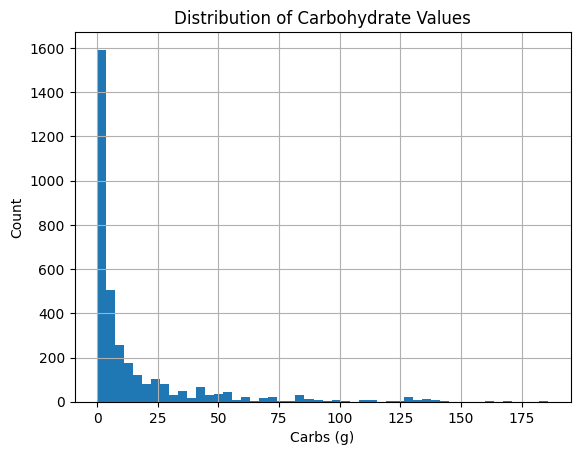

In [51]:
df["carb"].hist(bins=50)
plt.title("Distribution of Carbohydrate Values")
plt.xlabel("Carbs (g)")
plt.ylabel("Count")
plt.show()


# TODO
1. Augmentation test
2. Background removal

# Improvements on the regression model dataset
1. Log-transform the target (carb)-To reduce skew and stabilize variance
2. Normalize tabular features (area, intensity, aspect ratio)-This improves convergence
3. Use a smoother loss like SmoothL1Loss-This is less sensitive to outliers than MSELoss
# Experiments:
- https://pmc.ncbi.nlm.nih.gov/articles/PMC11887021/
- https://arxiv.org/html/2405.16478v1
- https://onlinelibrary.wiley.com/doi/10.1155/2023/6612302